<a href="https://colab.research.google.com/github/gabyx7677/proyectos_generales/blob/main/Proyecto_Sprint_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color:#f4a7b9; padding:10px; border-radius:5px;">
Descripción de las tarifas

Nota: Megaline redondea los segundos a minutos y los megabytes a gigabytes. Para las llamadas, cada llamada individual se redondea: incluso si la llamada duró solo un segundo, se contará como un minuto. Para el tráfico web, las sesiones web individuales no se redondean. En vez de esto, el total del mes se redondea hacia arriba. Si alguien usa 1025 megabytes este mes, se le cobrarán 2 gigabytes.

A continuación puedes ver una descripción de las tarifas:

Surf:

- Pago mensual: $20.

- 500 minutos al mes, 50 SMS y 15 GB de datos.
- Si se exceden los límites del paquete:
- 1 minuto: 3 centavos.
- 1 SMS: 3 centavos.
- 1 GB de datos: $10.

Ultimate:

- Pago mensual: $70.

- 3000 minutos al mes, 1000 SMS y 30 GB de datos.
- Si se exceden los límites del paquete:
- 1 minuto: 1 centavo.
- 1 SMS: 1 centavo.
- 1 GB de datos: $7.


Diccionario de datos
En este proyecto, trabajarás con cinco tablas diferentes.

La tabla users (datos sobre los usuarios):
- user_id: identificador único del usuario.
- first_name: nombre del usuario.
- last_name: apellido del usuario.
- age: edad del usuario (en años).
- reg_date: fecha de suscripción (dd, mm, aa).
- churn_date: la fecha en la que el usuario dejó de usar el servicio (si el valor es ausente, la tarifa se estaba usando cuando fue extraída esta base de datos).
- city: ciudad de residencia del usuario.
- plan: nombre de la tarifa.

La tabla calls (datos sobre las llamadas):
- id: identificador único de la llamada.
- call_date: fecha de la llamada.
- duration: duración de la llamada (en minutos).
- user_id: el identificador del usuario que realiza la llamada.

La tabla messages (datos sobre los SMS):
- id: identificador único del SMS.
- message_date: fecha del SMS.
- user_id: el identificador del usuario que manda el SMS.

La tabla internet (datos sobre las sesiones web):
- id: identificador único de la sesión.
- mb_used: el volumen de datos gastados durante la sesión (en megabytes).
- session_date: fecha de la sesión web.
- user_id: identificador del usuario.

La tabla plans (datos sobre las tarifas):
- plan_name: nombre de la tarifa.
- usd_monthly_fee: pago mensual en dólares estadounidenses.
- minutes_included: minutos incluidos al mes.
- messages_included: SMS incluidos al mes.
- mb_per_month_included: datos incluidos al mes (en megabytes).
- usd_per_minute: precio por minuto tras exceder los límites del paquete (por ejemplo, si el paquete incluye 100 minutos, el operador cobrará el minuto 101).
- usd_per_message: precio por SMS tras exceder los límites del paquete.
- usd_per_gb: precio por gigabyte de los datos extra tras exceder los límites del paquete (1 GB = 1024 megabytes).




</div>

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
1. Propósito del Proyecto:
El objetivo principal de este proyecto es identificar cuál de las dos tarifas de prepago ofrecidas por Megaline —Surf y Ultimate— genera mayores ingresos. Esta información permitirá al departamento comercial tomar decisiones informadas sobre cómo asignar de manera más eficiente el presupuesto de publicidad y así potenciar la rentabilidad de la empresa.

Plan de Acción
Para alcanzar este objetivo, seguiré los siguientes pasos:

Revisión y limpieza de los datos: Verificaré la calidad del conjunto de datos y corregiré posibles inconsistencias, valores nulos o atípicos.

Análisis exploratorio de datos (EDA): Analizaré el comportamiento de los clientes respecto al uso de llamadas, mensajes y datos móviles, segmentado por tarifa.

Cálculo de ingresos: Estimaré los ingresos mensuales generados por cada cliente en base a su tarifa, aplicando las condiciones de cada plan (minutos y mensajes incluidos, y cargos por excedente).

Comparación de tarifas: Evaluaré cuál de las dos tarifas genera mayores ingresos promedio y totales.

Prueba estadística: Aplicaré pruebas de hipótesis para determinar si las diferencias observadas en los ingresos entre las tarifas son estadísticamente significativas.

Conclusión y recomendaciones: Presentaré los hallazgos y sugerencias basadas en los datos analizados
</div>

## Inicialización

In [ ]:
# Cargar todas las librerías

# Análisis de datos
import pandas as pd
import numpy as np
import math
from scipy import stats

# Estadística
from scipy import stats as st

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Configuración estética opcional
sns.set(style='whitegrid')
plt.style.use('seaborn-v0_8-colorblind')

## Cargar datos

In [ ]:
# Carga los archivos de datos en diferentes DataFrames

csv = ['/content/megaline_calls.csv',
       '/content/megaline_internet.csv',
       '/content/megaline_messages.csv',
       '/content/megaline_plans.csv',
       '/content/megaline_users.csv']

names = ['calls', 'internet', 'messages', 'plans', 'users']
dfs = {name: pd.read_csv(path) for name, path in zip(names, csv)}

"""
No te enrredes, este código dfs = {name: pd.read_csv(path) for name, path in zip(names, csv)}
funciona de izquierda a derecha,y crea una lista de dfs que puedes llamar asignando
a una variable

🧠 Analogía rápida:
Como armar un sándwich:

Primero ponés los ingredientes (csv)

Luego los combinás (zip)

Después armás el pan con todo (dict comprehension)

Y al final, servís el plato (dfs)
"""

calls = dfs['calls']
internet = dfs['internet']
messages = dfs['messages']
plans = dfs['plans']
users = dfs['users']

## Preparar los datos

## Tarifas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [ ]:
# Imprime una muestra de los datos para las tarifas

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes




<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
El conjunto de datos plans contiene información sobre dos planes tarifarios, con un total de 8 columnas y sin valores nulos. Los tipos de datos son adecuados: se utilizan enteros para los recursos incluidos (mensajes, megabytes, minutos), flotantes para los costos unitarios y tipo objeto para el nombre del plan. Aunque no se requiere ninguna corrección crítica, se recomienda convertir la columna plan_name al tipo category para optimizar el uso de memoria y mejorar el rendimiento en operaciones futuras. El tamaño reducido del DataFrame indica que probablemente se utiliza como tabla de referencia, por lo que no se prevé un análisis estadístico profundo en esta instancia.
</div>

## Corregir datos



<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
Los datos se encuentran organizados incialmente ya que es un df categorico donde se describe el tipo de plan, se hace el cambio sugerido del tipo de dato objeto a categorico con el la idea de si a futuro se añaden planes se pueda modificar más fácilmente
</div>

In [ ]:
plans['plan_name'] = plans['plan_name'].astype('category')

In [ ]:
plans.info() # Se verifica el tipo de dato de la columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   messages_included      2 non-null      int64   
 1   mb_per_month_included  2 non-null      int64   
 2   minutes_included       2 non-null      int64   
 3   usd_monthly_pay        2 non-null      int64   
 4   usd_per_gb             2 non-null      int64   
 5   usd_per_message        2 non-null      float64 
 6   usd_per_minute         2 non-null      float64 
 7   plan_name              2 non-null      category
dtypes: category(1), float64(2), int64(5)
memory usage: 370.0 bytes





<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>Enriquecer los datos:<div>

En esta sección se comenzó reorganizando el DataFrame para colocar la columna plan_name como la primera, seguida de plan_type, lo que mejora la legibilidad y segmentación visual. Luego, se agregaron nuevas columnas para enriquecer el análisis: se estimó el costo adicional teórico por consumo excedente (estimated_extra_cost) y se calcularon los costos por unidad incluida en cada plan (cost_per_minute_included, cost_per_mb_included, cost_per_message_included). Además, se clasificaron los planes en categorías (Económico o Premium) con la columna plan_type, se estimó un costo total hipotético por sobreuso (hypothetical_total_cost) y se creó un indicador de valor relativo del plan (value_score), que resume cuántas unidades recibe el cliente por cada dólar pagado. Estas transformaciones permiten un análisis comparativo más profundo entre planes y sientan las bases para visualizaciones o decisiones estratégicas basadas en datos.
</div>

In [ ]:
plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [ ]:
# ENRIQUECIMIENTO DEL DATAFRAME 'plans'


# 1. Costo por unidad incluida dentro del plan mensual
# Esto permite comparar la eficiencia del plan en cuanto a costo por unidad consumida "incluida"
plans['cost_per_minute_included'] = plans['usd_monthly_pay'] / plans['minutes_included']
plans['cost_per_mb_included'] = plans['usd_monthly_pay'] / plans['mb_per_month_included']
plans['cost_per_message_included'] = plans['usd_monthly_pay'] / plans['messages_included']

# --------------------------------

# 2. Clasificación del tipo de plan (Ej: Económico vs Premium)
# Permite segmentar los planes para análisis más visual o categórico, si bien solo hay dos planes da una categorización
plans['plan_type'] = plans['usd_monthly_pay'].apply(lambda x: 'Premium' if x > 30 else 'Económico')

# --------------------------------

# 3. Valor relativo del plan: cuántas unidades ofrece por cada dólar pagado
# Permite comparar planes con una métrica objetiva de "valor" por dinero invertido
plans['value_score'] = (
    (plans['minutes_included'] + plans['mb_per_month_included'] / 1024 + plans['messages_included']) /
    plans['usd_monthly_pay']
)

# Reordenar las columnas para que 'plan_name' sea la primera
reordenar = ['plan_name'] + ['plan_type'] + [col for col in plans.columns if col not in  ['plan_name', 'plan_type']]
plans = plans[reordenar]

# Nota: los MB se dividen entre 1024 para convertir a GB, por una comparación más equitativa

In [ ]:
plans

,plan_name,plan_type,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,cost_per_minute_included,cost_per_mb_included,cost_per_message_included,value_score
0,surf,Económico,50,15360,500,20,10,0.03,0.03,0.040000,0.001302,0.40,28.250000
1,ultimate,Premium,1000,30720,3000,70,7,0.01,0.01,0.023333,0.002279,0.07,57.571429


## Usuarios/as

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

users.head(20)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaN
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaN
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaN
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaN


In [ ]:
# Imprime una muestra de datos para usuarios

users.sample(20)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
91,1091,Taylor,Oliver,38,"Riverside-San Bernardino-Ontario, CA MSA",2018-05-04,ultimate,NaN
23,1023,Jack,Delaney,70,"Omaha-Council Bluffs, NE-IA MSA",2018-07-06,surf,NaN
360,1360,Arturo,Mullins,75,"Charlotte-Concord-Gastonia, NC-SC MSA",2018-09-20,surf,NaN
159,1159,Dierdre,Baker,58,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-07-21,ultimate,NaN
53,1053,Piper,Espinoza,27,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-07-30,surf,NaN
431,1431,Napoleon,Burt,74,"Sacramento–Roseville–Folsom, CA MSA",2018-01-28,surf,NaN
385,1385,Nohemi,Erickson,52,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-01-19,surf,NaN
306,1306,Darron,Craig,19,"Washington-Arlington-Alexandria, DC-VA-MD-WV MSA",2018-11-26,surf,NaN
441,1441,Piedad,Myers,23,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-03-08,ultimate,2018-08-19
467,1467,Nickolas,Deleon,64,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-01-31,ultimate,2018-11-18


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


### Corregir los datos

<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>Enriquecer los datos:<div>

En esta sección se enriqueció el conjunto de datos users añadiendo variables clave que permiten una mejor segmentación y análisis del comportamiento de los clientes. Primero, se calculó la cantidad de días activos para cada usuario a partir de la fecha de registro y la fecha de cancelación (churn_date), usando la fecha actual en caso de que el usuario aún esté activo. Luego, se incorporó una columna booleana estatus: active que indica si el usuario sigue con la empresa. Para mejorar la consistencia de los datos, se estandarizó el texto en la columna plan, eliminando espacios y unificando el uso de minúsculas. Se creó también una columna categórica age_group que clasifica a los usuarios en grupos etarios (Joven, Adulto joven, Adulto, Senior), útil para análisis demográficos. Además, se generó una nueva columna full_name combinando nombre y apellido, y se eliminaron las columnas originales first_name y last_name para mantener el orden. Finalmente, se reorganizaron las columnas del DataFrame para facilitar la lectura y el análisis, ubicando primero los identificadores, datos demográficos y de plan, seguidos del estatus, antigüedad y fechas clave.
</div>


In [ ]:
users['city'].nunique()

73

In [ ]:
# Se revisa si los valores unicos contienen errores: "New york" y otro lugar "new york"
# Los datos se ven bastante consistentes y sin espacios al final o al principio
# Provienen de una fuente fiable y que filtra los datos al parecer de manera correcta
users['city'].sort_values().unique()

array(['Albany-Schenectady-Troy, NY MSA', 'Albuquerque, NM MSA',
       'Atlanta-Sandy Springs-Roswell, GA MSA',
       'Austin-Round Rock-Georgetown, TX MSA', 'Bakersfield, CA MSA',
       'Baltimore-Columbia-Towson, MD MSA', 'Baton Rouge, LA MSA',
       'Birmingham-Hoover, AL MSA', 'Boston-Cambridge-Newton, MA-NH MSA',
       'Bridgeport-Stamford-Norwalk, CT MSA',
       'Buffalo-Cheektowaga, NY MSA', 'Cape Coral-Fort Myers, FL MSA',
       'Charleston-North Charleston, SC MSA',
       'Charlotte-Concord-Gastonia, NC-SC MSA',
       'Chicago-Naperville-Elgin, IL-IN-WI MSA',
       'Cincinnati, OH-KY-IN MSA', 'Cleveland-Elyria, OH MSA',
       'Colorado Springs, CO MSA', 'Columbia, SC MSA', 'Columbus, OH MSA',
       'Dallas-Fort Worth-Arlington, TX MSA', 'Dayton-Kettering, OH MSA',
       'Denver-Aurora-Lakewood, CO MSA',
       'Detroit-Warren-Dearborn, MI MSA', 'El Paso, TX MSA',
       'Fresno, CA MSA', 'Grand Rapids-Kentwood, MI MSA',
       'Greensboro-High Point, NC MSA',
    

In [ ]:
# Solo se aplica un strip por si acaso en un dato hay algún espacio indeseado, las mayusculas no intervienen en el análisis
users['city'] = users['city'].str.strip()

In [ ]:
# Se cambia el formato de la columna churn_date y reg_date, no se eliminan los valores nulos
# Ya que no representan un error de análisis, el usuario no cancela por ende la fecha no existe
# No es necesario cambiarlo a menos que haya que operar con él
# Se cambia el user_id a string para que sea ininmutable a lo largo del análisis

users['churn_date'] = pd.to_datetime(users['churn_date'])
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['user_id'] = users['user_id'].astype(str)

In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    object        
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(5)
memory usage: 31.4+ KB


### Enriquecer los datos

In [ ]:
from datetime import datetime

# Se crea la columna de cantidad de días activo con el plan
# Se usa con el Timestamp
today = pd.Timestamp.today()
users['days_active'] = (users['churn_date'].fillna(today) - users['reg_date']).dt.days

# Se agrega una columna adicional que indica el estatus de los usuarios activo: True, inactivo: False
# Esto basandose en que si la columna de cancelación (churn_date) es un valor nulo
# Quiere decir que el plan sigue activo y al día
users['estatus: active'] = users['churn_date'].isna()

# Se estandariza users en caso de errores
users['plan'] = users['plan'].str.strip().str.lower()
users['plan'] = users['plan'].str.strip()

# Se agrega la columna agre_group con la idea de categorizar, a su vez el tipo de dato se tranforma en categoria
def clasifica_edad(edad):
    if edad < 25:
        return 'Joven'
    elif edad < 40:
        return 'Adulto joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Senior'

users['age_group'] = users['age'].apply(clasifica_edad).astype('category')
users['full_name'] = users['first_name'] + ' ' + users['last_name']
users.drop(['first_name', 'last_name'], axis=1, inplace=True)

In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          500 non-null    object        
 1   age              500 non-null    int64         
 2   city             500 non-null    object        
 3   reg_date         500 non-null    datetime64[ns]
 4   plan             500 non-null    object        
 5   churn_date       34 non-null     datetime64[ns]
 6   days_active      500 non-null    int64         
 7   estatus: active  500 non-null    bool          
 8   age_group        500 non-null    category      
 9   full_name        500 non-null    object        
dtypes: bool(1), category(1), datetime64[ns](2), int64(2), object(4)
memory usage: 32.6+ KB


In [ ]:
users

,user_id,age,city,reg_date,plan,churn_date,days_active,estatus: active,age_group,full_name
0,1000,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,2357,True,Adulto,Anamaria Bauer
1,1001,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2490,True,Adulto joven,Mickey Wilkerson
2,1002,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,2421,True,Adulto joven,Carlee Hoffman
3,1003,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,2687,True,Adulto,Reynaldo Jenkins
4,1004,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,2572,True,Adulto,Leonila Thompson
...,...,...,...,...,...,...,...,...,...,...
495,1495,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaT,2468,True,Senior,Fidel Sharpe
496,1496,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaT,2664,True,Adulto,Ariel Shepherd
497,1497,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaT,2371,True,Adulto,Donte Barrera
498,1498,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaT,2680,True,Adulto,Scot Williamson


In [ ]:
# Se reorganiza el dataframe
users = users[['user_id', 'full_name', 'age', 'age_group', 'plan', 'city', 'estatus: active', 'days_active', 'reg_date', 'churn_date']]
users

,user_id,full_name,age,age_group,plan,city,estatus: active,days_active,reg_date,churn_date
0,1000,Anamaria Bauer,45,Adulto,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",True,2357,2018-12-24,NaT
1,1001,Mickey Wilkerson,28,Adulto joven,surf,"Seattle-Tacoma-Bellevue, WA MSA",True,2490,2018-08-13,NaT
2,1002,Carlee Hoffman,36,Adulto joven,surf,"Las Vegas-Henderson-Paradise, NV MSA",True,2421,2018-10-21,NaT
3,1003,Reynaldo Jenkins,52,Adulto,surf,"Tulsa, OK MSA",True,2687,2018-01-28,NaT
4,1004,Leonila Thompson,40,Adulto,surf,"Seattle-Tacoma-Bellevue, WA MSA",True,2572,2018-05-23,NaT
...,...,...,...,...,...,...,...,...,...,...
495,1495,Fidel Sharpe,67,Senior,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,2468,2018-09-04,NaT
496,1496,Ariel Shepherd,49,Adulto,surf,"New Orleans-Metairie, LA MSA",True,2664,2018-02-20,NaT
497,1497,Donte Barrera,49,Adulto,ultimate,"Los Angeles-Long Beach-Anaheim, CA MSA",True,2371,2018-12-10,NaT
498,1498,Scot Williamson,51,Adulto,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,2680,2018-02-04,NaT


## Llamadas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

calls.head(20)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40


In [ ]:
# Imprime una muestra de datos para las llamadas

calls.sample(20)

,id,user_id,call_date,duration
65652,1237_259,1237,2018-10-10,6.58
57558,1206_372,1206,2018-08-17,15.74
49591,1179_250,1179,2018-11-26,4.30
92585,1333_114,1333,2018-11-26,0.00
34336,1127_159,1127,2018-11-28,5.17
51588,1185_626,1185,2018-12-23,8.72
129478,1465_942,1465,2018-10-02,2.93
5031,1022_297,1022,2018-07-14,18.89
33865,1126_752,1126,2018-09-30,19.57
31110,1117_84,1117,2018-10-05,5.16


In [ ]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB



<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
El DataFrame calls contiene 137,735 registros completos sobre llamadas realizadas por los usuarios, sin valores nulos, lo cual es positivo para el análisis. Sin embargo, presenta algunos aspectos a revisar: la columna call_date tiene un tipo de dato incorrecto (object) que debe convertirse a tipo datetime para permitir análisis temporales precisos. Además, se observan llamadas con duración igual a cero, lo que podría representar errores, llamadas fallidas o no conectadas, por lo que conviene investigarlas y decidir si deben excluirse del análisis. La columna id combina información del usuario y la llamada, pero no es útil tal cual para análisis numéricos, por lo que se puede ignorar o dividir si se requiere. Por otra parte, al analizar los planes tarifarios, se observa que existen dos planes (surf y ultimate) claramente diferenciados en minutos incluidos, precios y cargos por minuto adicional. Esta estructura tarifaria permite calcular fácilmente el costo real mensual por usuario si se agrupan las llamadas por usuario y mes, comparando los minutos consumidos con los minutos incluidos en su plan y aplicando las tarifas correspondientes a los minutos excedentes. Para lograr este análisis, es necesario preparar los datos adecuadamente, asegurando tipos de datos correctos y depurando valores anómalos.

</div>

### Corregir los datos

In [ ]:
"""
NORMALIZAR LOS IDS DE LAS LLAMADAS, ES DECIR, QUE QUEDEN DEL MISMO TAMAÑO TODOS, QUIZAS AÑADIENDO CEROS, PUEDE SER ÚTIL
"""
# Función para formatear el id y añadir los ceros correspondientes
def formatear_id(id_str, len_izq=4, len_der=4):
    parte1, parte2 = id_str.split('_')
    parte1 = parte1.zfill(len_izq)                    # ceros a la izquierda
    parte2 = parte2 + '0' * (len_der - len(parte2))   # ceros a la derecha
    return f"{parte1}_{parte2}"

calls['id'] = calls['id'].astype(str).apply(formatear_id)
calls['user_id'] = calls['user_id'].astype(str)
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls

,id,user_id,call_date,duration
0,1000_9300,1000,2018-12-27,8.52
1,1000_1450,1000,2018-12-27,13.66
2,1000_2470,1000,2018-12-27,14.48
3,1000_3090,1000,2018-12-28,5.76
4,1000_3800,1000,2018-12-30,4.22
...,...,...,...,...
137730,1499_1990,1499,2018-11-21,8.72
137731,1499_2000,1499,2018-10-20,10.89
137732,1499_2010,1499,2018-09-21,8.12
137733,1499_2020,1499,2018-10-10,0.37


In [ ]:
calls.sample(20)

,id,user_id,call_date,duration
48536,1174_5130,1174,2018-12-18,18.17
116345,1407_7200,1407,2018-12-23,5.48
84764,1312_2560,1312,2018-04-04,0.00
3494,1011_3470,1011,2018-07-24,22.61
57041,1203_4320,1203,2018-05-22,13.74
81663,1294_1300,1294,2018-10-07,0.00
52558,1188_4000,1188,2018-11-26,4.92
99993,1358_4190,1358,2018-08-01,4.78
26508,1100_6500,1100,2018-11-27,1.06
127169,1454_1590,1454,2018-09-05,0.00


In [ ]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  object        
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 4.2+ MB


### Enriquecer los datos





<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Primero, normalicé los IDs de las llamadas para que tuvieran un formato uniforme. Para eso, apliqué una función que rellena con ceros a la izquierda y derecha las partes del ID separadas por guion bajo, asegurando que todos quedaran del mismo tamaño. Esto facilita la lectura y el manejo del identificador en análisis posteriores. También convertí la columna user_id a tipo string para mantener consistencia y transformé call_date al tipo datetime, lo cual es esencial para trabajar correctamente con fechas y poder hacer análisis temporales.

Después, enriquecí el DataFrame extrayendo componentes clave de la fecha de cada llamada: el día, mes, año y día de la semana. Esto me permite analizar patrones de uso según el calendario. Además, clasifiqué las llamadas según su duración en tres categorías: corta, media o larga, lo que puede ser útil para visualizar tendencias de comportamiento. Por último, añadí una columna booleana llamada is_real_call para distinguir las llamadas reales de aquellas con duración cero, que podrían ser intentos fallidos, spam o errores del sistema. Con estas transformaciones, dejé los datos listos para un análisis mucho más profundo y confiable.

</div>

In [ ]:
# Se extraen esto valores para poder medir y escalar niveles de llamadas por meses, días, horas del día
# Y poder hacer un análisis a profundidad en estas variables

calls['day'] = calls['call_date'].dt.day
calls['month'] = calls['call_date'].dt.month
calls['year'] = calls['call_date'].dt.year
calls['weekday'] = calls['call_date'].dt.day_name()  # lunes, martes, etc.

# Clasificar el tipo de llamada según su duración, esto puede servir a despues
# Para mostrar gráficas de tendencia según categorías
def clasificar_llamada(duracion):
    if duracion < 1:
        return 'corta'
    elif duracion < 5:
        return 'media'
    else:
        return 'larga'

calls['call_type'] = calls['duration'].apply(clasificar_llamada).astype('category')

# Clasificar llamadas que pueden ser consideradas Fake o Spam
calls['is_real_call'] = calls['duration'] > 0

calls = calls[['id', 'user_id', 'call_date', 'duration', 'day', 'month', 'year', 'weekday', 'call_type', 'is_real_call']]
calls

,id,user_id,call_date,duration,day,month,year,weekday,call_type,is_real_call
0,1000_9300,1000,2018-12-27,8.52,27,12,2018,Thursday,larga,True
1,1000_1450,1000,2018-12-27,13.66,27,12,2018,Thursday,larga,True
2,1000_2470,1000,2018-12-27,14.48,27,12,2018,Thursday,larga,True
3,1000_3090,1000,2018-12-28,5.76,28,12,2018,Friday,larga,True
4,1000_3800,1000,2018-12-30,4.22,30,12,2018,Sunday,media,True
...,...,...,...,...,...,...,...,...,...,...
137730,1499_1990,1499,2018-11-21,8.72,21,11,2018,Wednesday,larga,True
137731,1499_2000,1499,2018-10-20,10.89,20,10,2018,Saturday,larga,True
137732,1499_2010,1499,2018-09-21,8.12,21,9,2018,Friday,larga,True
137733,1499_2020,1499,2018-10-10,0.37,10,10,2018,Wednesday,corta,True


In [ ]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            137735 non-null  object        
 1   user_id       137735 non-null  object        
 2   call_date     137735 non-null  datetime64[ns]
 3   duration      137735 non-null  float64       
 4   day           137735 non-null  int32         
 5   month         137735 non-null  int32         
 6   year          137735 non-null  int32         
 7   weekday       137735 non-null  object        
 8   call_type     137735 non-null  category      
 9   is_real_call  137735 non-null  bool          
dtypes: bool(1), category(1), datetime64[ns](1), float64(1), int32(3), object(3)
memory usage: 7.1+ MB


## Mensajes

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

messages.head(20)

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
5,1000_346,1000,2018-12-29
6,1000_386,1000,2018-12-30
7,1000_413,1000,2018-12-31
8,1000_502,1000,2018-12-27
9,1000_525,1000,2018-12-28


In [ ]:
# Imprime una muestra de datos para los mensajes

messages.sample(20)

,id,user_id,message_date
39183,1255_227,1255,2018-12-30
40771,1261_437,1261,2018-11-17
45933,1313_129,1313,2018-07-17
64589,1412_171,1412,2018-12-19
35708,1235_34,1235,2018-12-06
6897,1057_221,1057,2018-11-25
62832,1396_116,1396,2018-10-05
54850,1346_359,1346,2018-12-02
54249,1343_340,1343,2018-12-22
30385,1191_90,1191,2018-09-17


In [ ]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB





<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
El DataFrame messages contiene 76,051 registros sin datos nulos y con una estructura general bien definida; sin embargo, presenta algunos aspectos a mejorar: la columna message_date está en formato object y debe convertirse a tipo datetime para permitir análisis temporales, y el campo user_id podría transformarse a str para mantener consistencia con otros DataFrames como calls. Además, sería útil estandarizar el formato del campo id (por ejemplo, añadiendo ceros) para facilitar su uso en análisis comparativos o uniones entre tablas.

</div>

### Corregir los datos

In [ ]:
"""
NORMALIZAR LOS IDS DE LOS MENSJAES, ES DECIR, QUE QUEDEN DEL MISMO TAMAÑO TODOS, QUIZAS AÑADIENDO CEROS, PUEDE SER UTIL
"""
# función para formatear el id y añadir los ceros correspondientes
def formatear_id(id_str, len_izq=4, len_der=4):
    parte1, parte2 = id_str.split('_')
    parte1 = parte1.zfill(len_izq)                    # ceros a la izquierda
    parte2 = parte2 + '0' * (len_der - len(parte2))   # ceros a la derecha
    return f"{parte1}_{parte2}"

messages['id'] = messages['id'].astype(str).apply(formatear_id)
messages['user_id'] = messages['user_id'].astype(str)
messages['message_date'] = pd.to_datetime(messages['message_date'])
messages

,id,user_id,message_date
0,1000_1250,1000,2018-12-27
1,1000_1600,1000,2018-12-31
2,1000_2230,1000,2018-12-31
3,1000_2510,1000,2018-12-27
4,1000_2550,1000,2018-12-26
...,...,...,...
76046,1497_5260,1497,2018-12-24
76047,1497_5360,1497,2018-12-24
76048,1497_5470,1497,2018-12-31
76049,1497_5580,1497,2018-12-24


In [ ]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  object        
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 1.7+ MB


### Enriquecer los datos




<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Primero normalicé los identificadores de los mensajes (id) para que todos tuvieran el mismo formato, añadiendo ceros a la izquierda y a la derecha según fuera necesario. También convertí el campo user_id a tipo cadena para mantener consistencia con otros DataFrames, y transformé message_date a tipo datetime para poder trabajar fácilmente con fechas. Luego enriquecí los datos extrayendo información temporal como el día, mes, año y día de la semana a partir de la fecha del mensaje, lo que me permitirá hacer análisis más detallados y segmentados. Finalmente, reorganicé las columnas para dejar el DataFrame más limpio y ordenado.

</div>

In [ ]:
# Se extraen esto valores para poder medir y escalar niveles de mensajes por meses, días, horas del día
# Y poder hacer un análisis a profundidad en estas variables

messages['day'] = messages['message_date'].dt.day
messages['month'] = messages['message_date'].dt.month
messages['year'] = messages['message_date'].dt.year
messages['weekday'] = messages['message_date'].dt.day_name()  # lunes, martes, etc.

# Se reorganiza el df
messages = messages[['id', 'user_id', 'message_date', 'day', 'month', 'year', 'weekday']]
messages

,id,user_id,message_date,day,month,year,weekday
0,1000_1250,1000,2018-12-27,27,12,2018,Thursday
1,1000_1600,1000,2018-12-31,31,12,2018,Monday
2,1000_2230,1000,2018-12-31,31,12,2018,Monday
3,1000_2510,1000,2018-12-27,27,12,2018,Thursday
4,1000_2550,1000,2018-12-26,26,12,2018,Wednesday
...,...,...,...,...,...,...,...
76046,1497_5260,1497,2018-12-24,24,12,2018,Monday
76047,1497_5360,1497,2018-12-24,24,12,2018,Monday
76048,1497_5470,1497,2018-12-31,31,12,2018,Monday
76049,1497_5580,1497,2018-12-24,24,12,2018,Monday


## Internet

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.head(20)

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
5,1001_0,1001,2018-08-24,284.68
6,1001_3,1001,2018-12-09,656.04
7,1001_4,1001,2018-11-04,16.97
8,1001_10,1001,2018-11-27,135.18
9,1001_15,1001,2018-12-13,761.92


In [ ]:
# Imprime una muestra de datos para el tráfico de internet

internet.sample(20)

,id,user_id,session_date,mb_used
3674,1022_85,1022,2018-12-01,262.40
82640,1385_391,1385,2018-06-04,229.69
8037,1043_98,1043,2018-09-30,526.86
21077,1098_108,1098,2018-09-15,547.98
86732,1403_80,1403,2018-07-24,0.00
8017,1043_66,1043,2018-09-27,81.73
51509,1232_38,1232,2018-11-28,207.05
62194,1283_92,1283,2018-12-31,318.01
85756,1399_368,1399,2018-06-27,210.76
92031,1427_36,1427,2018-09-22,1001.08


In [ ]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB




<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
El DataFrame internet contiene 104,825 registros distribuidos en 4 columnas: id, user_id, session_date y mb_used. No presenta valores nulos, lo cual es positivo, pero hay algunas observaciones importantes: los tipos de datos parecen adecuados salvo session_date, que está como objeto (string) y debería convertirse a tipo fecha (datetime) para facilitar análisis temporales. Además, en la columna mb_used, se observan valores de 0.00 MB, lo cual puede indicar sesiones vacías, errores de registro o casos especiales que merecen ser investigados. Una limpieza mínima implicaría convertir session_date a tipo fecha y analizar si los registros con 0 MB deben excluirse o marcarse para un tratamiento específico.

</div>

### Corregir los datos

In [ ]:
internet['mb_used'].describe()

,mb_used
count,104825.000000
mean,366.713701
std,277.170542
min,0.000000
25%,136.080000
50%,343.980000
75%,554.610000
max,1693.470000


In [ ]:
"""
NORMALIZAR LOS IDS DE LOS MENSJAES, ES DECIR, QUE QUEDEN DEL MISMO TAMAÑO TODOS, QUIZAS AÑADIENDO CEROS, PUEDE SER UTIL
"""
# función para formatear el id y añadir los ceros correspondientes
def formatear_id(id_str, len_izq=4, len_der=4):
    parte1, parte2 = id_str.split('_')
    parte1 = parte1.zfill(len_izq)                    # ceros a la izquierda
    parte2 = parte2 + '0' * (len_der - len(parte2))   # ceros a la derecha
    return f"{parte1}_{parte2}"


# Se limpian y estandarizan las columnas necesarias para que se facilite el manejo de datos

internet['id'] = internet['id'].astype(str).apply(formatear_id)
internet['user_id'] = internet['user_id'].astype(str)
internet['session_date'] = pd.to_datetime(internet['session_date'])

### Enriquecer los datos



<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Primero me encargué de limpiar y estandarizar los datos del DataFrame internet. Normalicé los IDs para que tuvieran un formato uniforme, añadiendo ceros a la izquierda y derecha cuando era necesario, lo cual facilita el análisis y evita errores de comparación. También convertí los valores de user_id a tipo string y transformé la columna session_date a formato datetime para poder trabajar cómodamente con fechas. Luego, enriquecí el conjunto de datos extrayendo el día, mes, año y nombre del día de la semana a partir de la fecha de sesión, permitiéndome así analizar patrones temporales. Finalmente, creé una nueva columna categórica llamada usage_level para clasificar el consumo de megabytes (mb_used) en niveles bajo, medio y alto, con base en rangos definidos tras una inspección inicial. Esto dejó el DataFrame listo para análisis más detallados y visualizaciones.

</div>

In [ ]:
# Se agregan columnas para dividir por días, meses, y años y así realizar análisis a profundidad
internet['day'] = internet['session_date'].dt.day
internet['month'] = internet['session_date'].dt.month
internet['year'] = internet['session_date'].dt.year
internet['weekday'] = internet['session_date'].dt.day_name()  # 'Monday', 'Tuesday', etc.

# Se crea una columna categorica dados los intervalos
# Estos intervalos se sacaron luego de ver el consumo de mb_used con un describe()
internet['usage_level'] = pd.cut(
    internet['mb_used'],
    bins=[-1, 100, 500, float('inf')],
    labels=['bajo', 'medio', 'alto']
)

# Se reorganiza el df y se muestra
internet = internet[['id', 'user_id', 'mb_used', 'usage_level', 'session_date', 'day', 'month', 'year', 'weekday']]
internet

,id,user_id,mb_used,usage_level,session_date,day,month,year,weekday
0,1000_1300,1000,89.86,bajo,2018-12-29,29,12,2018,Saturday
1,1000_2040,1000,0.00,bajo,2018-12-31,31,12,2018,Monday
2,1000_3790,1000,660.40,alto,2018-12-28,28,12,2018,Friday
3,1000_4130,1000,270.99,medio,2018-12-26,26,12,2018,Wednesday
4,1000_4420,1000,880.22,alto,2018-12-27,27,12,2018,Thursday
...,...,...,...,...,...,...,...,...,...
104820,1499_2150,1499,218.06,medio,2018-10-20,20,10,2018,Saturday
104821,1499_2160,1499,304.72,medio,2018-12-30,30,12,2018,Sunday
104822,1499_2170,1499,292.75,medio,2018-09-22,22,9,2018,Saturday
104823,1499_2180,1499,0.00,bajo,2018-12-07,7,12,2018,Friday


In [ ]:
internet_user_summary = internet.groupby('user_id').agg(
    sessions=('id', 'count'),
    total_mb_used=('mb_used', 'sum'),
    avg_session_mb=('mb_used', 'mean')
).reset_index()

internet_user_summary

,user_id,sessions,total_mb_used,avg_session_mb
0,1000,5,1901.47,380.294000
1,1001,245,80437.94,328.318122
2,1002,124,40293.33,324.946210
3,1003,52,27044.14,520.079615
4,1004,460,156352.81,339.897413
...,...,...,...,...
484,1495,290,98890.96,341.003310
485,1496,225,64268.64,285.638400
486,1497,31,11106.55,358.275806
487,1498,657,227525.13,346.309178


## Estudiar las condiciones de las tarifas

In [ ]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans

,plan_name,plan_type,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,cost_per_minute_included,cost_per_mb_included,cost_per_message_included,value_score
0,surf,Económico,50,15360,500,20,10,0.03,0.03,0.040000,0.001302,0.40,28.250000
1,ultimate,Premium,1000,30720,3000,70,7,0.01,0.01,0.023333,0.002279,0.07,57.571429


In [ ]:
users

,user_id,full_name,age,age_group,plan,city,estatus: active,days_active,reg_date,churn_date
0,1000,Anamaria Bauer,45,Adulto,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",True,2357,2018-12-24,NaT
1,1001,Mickey Wilkerson,28,Adulto joven,surf,"Seattle-Tacoma-Bellevue, WA MSA",True,2490,2018-08-13,NaT
2,1002,Carlee Hoffman,36,Adulto joven,surf,"Las Vegas-Henderson-Paradise, NV MSA",True,2421,2018-10-21,NaT
3,1003,Reynaldo Jenkins,52,Adulto,surf,"Tulsa, OK MSA",True,2687,2018-01-28,NaT
4,1004,Leonila Thompson,40,Adulto,surf,"Seattle-Tacoma-Bellevue, WA MSA",True,2572,2018-05-23,NaT
...,...,...,...,...,...,...,...,...,...,...
495,1495,Fidel Sharpe,67,Senior,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,2468,2018-09-04,NaT
496,1496,Ariel Shepherd,49,Adulto,surf,"New Orleans-Metairie, LA MSA",True,2664,2018-02-20,NaT
497,1497,Donte Barrera,49,Adulto,ultimate,"Los Angeles-Long Beach-Anaheim, CA MSA",True,2371,2018-12-10,NaT
498,1498,Scot Williamson,51,Adulto,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,2680,2018-02-04,NaT


In [ ]:
calls

,id,user_id,call_date,duration,day,month,year,weekday,call_type,is_real_call
0,1000_9300,1000,2018-12-27,8.52,27,12,2018,Thursday,larga,True
1,1000_1450,1000,2018-12-27,13.66,27,12,2018,Thursday,larga,True
2,1000_2470,1000,2018-12-27,14.48,27,12,2018,Thursday,larga,True
3,1000_3090,1000,2018-12-28,5.76,28,12,2018,Friday,larga,True
4,1000_3800,1000,2018-12-30,4.22,30,12,2018,Sunday,media,True
...,...,...,...,...,...,...,...,...,...,...
137730,1499_1990,1499,2018-11-21,8.72,21,11,2018,Wednesday,larga,True
137731,1499_2000,1499,2018-10-20,10.89,20,10,2018,Saturday,larga,True
137732,1499_2010,1499,2018-09-21,8.12,21,9,2018,Friday,larga,True
137733,1499_2020,1499,2018-10-10,0.37,10,10,2018,Wednesday,corta,True


In [ ]:
messages

,id,user_id,message_date,day,month,year,weekday
0,1000_1250,1000,2018-12-27,27,12,2018,Thursday
1,1000_1600,1000,2018-12-31,31,12,2018,Monday
2,1000_2230,1000,2018-12-31,31,12,2018,Monday
3,1000_2510,1000,2018-12-27,27,12,2018,Thursday
4,1000_2550,1000,2018-12-26,26,12,2018,Wednesday
...,...,...,...,...,...,...,...
76046,1497_5260,1497,2018-12-24,24,12,2018,Monday
76047,1497_5360,1497,2018-12-24,24,12,2018,Monday
76048,1497_5470,1497,2018-12-31,31,12,2018,Monday
76049,1497_5580,1497,2018-12-24,24,12,2018,Monday


In [ ]:
internet

,id,user_id,mb_used,usage_level,session_date,day,month,year,weekday
0,1000_1300,1000,89.86,bajo,2018-12-29,29,12,2018,Saturday
1,1000_2040,1000,0.00,bajo,2018-12-31,31,12,2018,Monday
2,1000_3790,1000,660.40,alto,2018-12-28,28,12,2018,Friday
3,1000_4130,1000,270.99,medio,2018-12-26,26,12,2018,Wednesday
4,1000_4420,1000,880.22,alto,2018-12-27,27,12,2018,Thursday
...,...,...,...,...,...,...,...,...,...
104820,1499_2150,1499,218.06,medio,2018-10-20,20,10,2018,Saturday
104821,1499_2160,1499,304.72,medio,2018-12-30,30,12,2018,Sunday
104822,1499_2170,1499,292.75,medio,2018-09-22,22,9,2018,Saturday
104823,1499_2180,1499,0.00,bajo,2018-12-07,7,12,2018,Friday


## Agregar datos por usuario



In [ ]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
# Se saca un df para ver la cantidad de llamadas realizadas por usuario
calls_made_users_summary = calls.groupby('user_id')['id'].count().reset_index()
calls_made_users_summary.columns = ['user_id', 'calls_made']
calls_made_users_summary

,user_id,calls_made
0,1000,16
1,1001,261
2,1002,113
3,1003,149
4,1004,370
...,...,...
476,1495,253
477,1496,195
478,1497,54
479,1498,451


<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Agrupé los datos por cada usuario para obtener un resumen claro de su comportamiento. Calculé cuántas llamadas realizó y cuanto tiempo duró en llamada cada uno de los usuarios y tener un panorama más claro


</div>

In [ ]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
calls_minutes_users_summary = calls.groupby('user_id')['duration'].sum().reset_index()
calls_minutes_users_summary.columns = ['user_id', 'total_duration']
calls_minutes_users_summary

,user_id,total_duration
0,1000,116.83
1,1001,1640.46
2,1002,777.13
3,1003,1041.00
4,1004,2618.95
...,...,...
476,1495,1666.41
477,1496,1376.21
478,1497,276.53
479,1498,3029.97


<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Agrupé los datos por cada usuario para obtener un resumen claro de su comportamiento. Calculé cuántas mensajes enviados que tuvo cada uno y tener un panorama más claro


</div>

In [ ]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
# Se saca un df para ver la cantidad de mensajes realizados por usuario
messages_sended_users_summary = messages.groupby('user_id')['id'].count().reset_index()
messages_sended_users_summary.columns = ['user_id', 'messages_sended']
messages_sended_users_summary

,user_id,messages_sended
0,1000,11
1,1001,207
2,1002,88
3,1003,50
4,1004,177
...,...,...
397,1491,409
398,1492,108
399,1494,174
400,1496,65


<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Agrupé los datos por cada usuario para obtener un resumen claro de su comportamiento. Calculé cuántas sesiones tuvo cada uno, cuánto total de megas consumió y cuál fue el promedio de megas usados por sesión. Así, puedo entender mejor el uso individual de internet de forma rápida y precisa.


</div>

In [ ]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

internet_user_summary = internet.groupby('user_id').agg(
    sessions=('id', 'count'),
    total_mb_used=('mb_used', 'sum'),
    avg_session_mb=('mb_used', 'mean')
).reset_index()

internet_user_summary

,user_id,sessions,total_mb_used,avg_session_mb
0,1000,5,1901.47,380.294000
1,1001,245,80437.94,328.318122
2,1002,124,40293.33,324.946210
3,1003,52,27044.14,520.079615
4,1004,460,156352.81,339.897413
...,...,...,...,...
484,1495,290,98890.96,341.003310
485,1496,225,64268.64,285.638400
486,1497,31,11106.55,358.275806
487,1498,657,227525.13,346.309178




<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Se fusionó el dataframe para poder tener una sola base de datos agrupada por usuario y ver su comportamiento individual, esto nos da información sobre los consumos de cada uno y nos permite análisar la información con mas profundidad.

</div>

In [ ]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# Acá ya se define que el tiempo para tomar los consumos será mensualmente

calls_monthly = calls.groupby(['user_id', 'month']).agg(
    calls_total=('id', 'count'),
    total_minutes=('duration', 'sum')
).reset_index()

messages_monthly = messages.groupby(['user_id', 'month']).agg(
    messages_total=('id', 'count')
).reset_index()

internet_monthly = internet.groupby(['user_id', 'month']).agg(
    mb_total=('mb_used', 'sum'),
    avg_session_mb=('mb_used', 'mean')
).reset_index()

from functools import reduce

dfs = [calls_monthly, messages_monthly, internet_monthly]

# Combina los tres dataframes usando merge progresiva
full_usage = reduce(lambda left, right: pd.merge(left, right, on=['user_id', 'month'], how='outer'), dfs)

# Rellena NaNs por si algún usuario no usó cierto servicio ese mes
full_usage = full_usage.fillna(0)

full_usage # Se unen los df y queda un df general con consumos totales de los servicios de manera mensual

,user_id,month,calls_total,total_minutes,messages_total,mb_total,avg_session_mb
0,1000,12,16.0,116.83,11.0,1901.47,380.294000
1,1001,8,27.0,171.14,30.0,6919.15,276.766000
2,1001,9,49.0,297.69,44.0,13314.82,251.223019
3,1001,10,65.0,374.11,53.0,22330.49,398.758750
4,1001,11,64.0,404.59,36.0,18504.30,362.829412
...,...,...,...,...,...,...,...
2288,1498,12,39.0,324.77,0.0,23137.69,355.964462
2289,1499,9,41.0,330.37,0.0,12984.76,288.550222
2290,1499,10,53.0,363.28,0.0,19492.43,319.548033
2291,1499,11,45.0,288.56,0.0,16813.83,343.139388


In [ ]:
# Añade la información de la tarifa
# Se añade la información del df users para completar
# Se reorganiza el df
full_data_per_user = full_usage.merge(users, on='user_id', how='left')
full_data_per_user = full_data_per_user[['user_id',
                                        'full_name',
                                        'plan',
                                        'age',
                                        'age_group',
                                        'city',
                                        'estatus: active',
                                        'calls_total',
                                        'total_minutes',
                                        'messages_total',
                                        'mb_total',
                                        'avg_session_mb',
                                        'days_active',
                                        'reg_date',
                                        'month']]

full_data_per_user

,user_id,full_name,plan,age,age_group,city,estatus: active,calls_total,total_minutes,messages_total,mb_total,avg_session_mb,days_active,reg_date,month
0,1000,Anamaria Bauer,ultimate,45,Adulto,"Atlanta-Sandy Springs-Roswell, GA MSA",True,16.0,116.83,11.0,1901.47,380.294000,2357,2018-12-24,12
1,1001,Mickey Wilkerson,surf,28,Adulto joven,"Seattle-Tacoma-Bellevue, WA MSA",True,27.0,171.14,30.0,6919.15,276.766000,2490,2018-08-13,8
2,1001,Mickey Wilkerson,surf,28,Adulto joven,"Seattle-Tacoma-Bellevue, WA MSA",True,49.0,297.69,44.0,13314.82,251.223019,2490,2018-08-13,9
3,1001,Mickey Wilkerson,surf,28,Adulto joven,"Seattle-Tacoma-Bellevue, WA MSA",True,65.0,374.11,53.0,22330.49,398.758750,2490,2018-08-13,10
4,1001,Mickey Wilkerson,surf,28,Adulto joven,"Seattle-Tacoma-Bellevue, WA MSA",True,64.0,404.59,36.0,18504.30,362.829412,2490,2018-08-13,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1498,Scot Williamson,surf,51,Adulto,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,39.0,324.77,0.0,23137.69,355.964462,2680,2018-02-04,12
2289,1499,Shena Dickson,surf,37,Adulto joven,"Orlando-Kissimmee-Sanford, FL MSA",True,41.0,330.37,0.0,12984.76,288.550222,2589,2018-05-06,9
2290,1499,Shena Dickson,surf,37,Adulto joven,"Orlando-Kissimmee-Sanford, FL MSA",True,53.0,363.28,0.0,19492.43,319.548033,2589,2018-05-06,10
2291,1499,Shena Dickson,surf,37,Adulto joven,"Orlando-Kissimmee-Sanford, FL MSA",True,45.0,288.56,0.0,16813.83,343.139388,2589,2018-05-06,11




<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Definí un diccionario con las características y tarifas de cada plan para tener la información centralizada y clara. Luego, creé una función que calcula el ingreso mensual por usuario, restando del total consumido los límites gratuitos incluidos en su plan y multiplicando los excedentes por sus tarifas correspondientes. Finalmente, sumo la tarifa fija mensual del plan con el costo por los consumos extras para obtener el ingreso total generado por cada usuario en el mes.

</div>

In [ ]:
# Calcula el ingreso mensual para cada usuario



plan_details = {
    'surf': {
        'usd_monthly_fee': 20,
        'minutes_included': 500,
        'messages_included': 50,
        'mb_included': 15 * 1024,  # en MB
        'usd_per_minute': 0.03,
        'usd_per_message': 0.03,
        'usd_per_gb': 10
    },
    'ultimate': {
        'usd_monthly_fee': 70,
        'minutes_included': 3000,
        'messages_included': 1000,
        'mb_included': 30 * 1024,
        'usd_per_minute': 0.01,
        'usd_per_message': 0.01,
        'usd_per_gb': 7
    }
}


def calcular_ingresos(row):
    plan = row['plan']
    detalles = plan_details[plan]

    # Excesos
    extra_minutes = max(0, row['total_minutes'] - detalles['minutes_included'])
    extra_messages = max(0, row['messages_total'] - detalles['messages_included'])

    # Convertir MB → GB (redondeado hacia arriba)
    total_gb = math.ceil(row['mb_total'] / 1024)
    included_gb = detalles['mb_included'] / 1024
    extra_gb = max(0, total_gb - included_gb)

    # Costo por excedentes
    extra_cost = (
        extra_minutes * detalles['usd_per_minute'] +
        extra_messages * detalles['usd_per_message'] +
        extra_gb * detalles['usd_per_gb']
    )

    # Ingreso total = mensual fijo + excedentes
    return detalles['usd_monthly_fee'] + extra_cost

full_data_per_user['monthly_revenue_&_extra'] = full_data_per_user.apply(calcular_ingresos, axis=1)

full_data_per_user # ESTE ES UN DF PARA CADA USUARIO EN DONDE SE VE EL CONGLOMERADO TOTAL MENSUAL DE SUS CONSUMOS, CADA FILA ES UN MES DIFERENTE


,user_id,full_name,plan,age,age_group,city,estatus: active,calls_total,total_minutes,messages_total,mb_total,avg_session_mb,days_active,reg_date,month,monthly_revenue_&_extra
0,1000,Anamaria Bauer,ultimate,45,Adulto,"Atlanta-Sandy Springs-Roswell, GA MSA",True,16.0,116.83,11.0,1901.47,380.294000,2357,2018-12-24,12,70.00
1,1001,Mickey Wilkerson,surf,28,Adulto joven,"Seattle-Tacoma-Bellevue, WA MSA",True,27.0,171.14,30.0,6919.15,276.766000,2490,2018-08-13,8,20.00
2,1001,Mickey Wilkerson,surf,28,Adulto joven,"Seattle-Tacoma-Bellevue, WA MSA",True,49.0,297.69,44.0,13314.82,251.223019,2490,2018-08-13,9,20.00
3,1001,Mickey Wilkerson,surf,28,Adulto joven,"Seattle-Tacoma-Bellevue, WA MSA",True,65.0,374.11,53.0,22330.49,398.758750,2490,2018-08-13,10,90.09
4,1001,Mickey Wilkerson,surf,28,Adulto joven,"Seattle-Tacoma-Bellevue, WA MSA",True,64.0,404.59,36.0,18504.30,362.829412,2490,2018-08-13,11,60.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1498,Scot Williamson,surf,51,Adulto,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,39.0,324.77,0.0,23137.69,355.964462,2680,2018-02-04,12,100.00
2289,1499,Shena Dickson,surf,37,Adulto joven,"Orlando-Kissimmee-Sanford, FL MSA",True,41.0,330.37,0.0,12984.76,288.550222,2589,2018-05-06,9,20.00
2290,1499,Shena Dickson,surf,37,Adulto joven,"Orlando-Kissimmee-Sanford, FL MSA",True,53.0,363.28,0.0,19492.43,319.548033,2589,2018-05-06,10,70.00
2291,1499,Shena Dickson,surf,37,Adulto joven,"Orlando-Kissimmee-Sanford, FL MSA",True,45.0,288.56,0.0,16813.83,343.139388,2589,2018-05-06,11,40.00


In [ ]:
full_data_per_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  2293 non-null   object        
 1   full_name                2293 non-null   object        
 2   plan                     2293 non-null   object        
 3   age                      2293 non-null   int64         
 4   age_group                2293 non-null   category      
 5   city                     2293 non-null   object        
 6   estatus: active          2293 non-null   bool          
 7   calls_total              2293 non-null   float64       
 8   total_minutes            2293 non-null   float64       
 9   messages_total           2293 non-null   float64       
 10  mb_total                 2293 non-null   float64       
 11  avg_session_mb           2293 non-null   float64       
 12  days_active              2293 non-

## Estudia el comportamiento de usuario

### Llamadas

In [ ]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
full_data_per_user.groupby(['plan', 'month'])['total_minutes'].describe()

count        mean         std     min       25%      50%  \
plan     month                                                             
surf     1        2.0  192.840000  121.636508  106.83  149.8350  192.840   
         2        9.0  280.851111  216.700761   36.82  231.8700  240.660   
         3       23.0  310.970000  178.385308   33.43  217.7350  312.790   
         4       50.0  332.380000  213.578245   15.69  171.1125  320.120   
         5       77.0  377.053247  230.830939    0.00  174.1500  387.450   
         6       97.0  407.208866  201.887744    0.00  279.4400  400.280   
         7      121.0  424.523223  233.311346    0.00  287.2600  430.060   
         8      162.0  387.169630  220.490503    0.00  242.9675  367.110   
         9      194.0  390.992062  203.912959    0.00  247.6500  401.520   
         10     237.0  405.692363  216.174537    0.00  245.9900  407.590   
         11     283.0  399.599823  214.720949    0.00  252.1100  392.100   
         12     318.0  447.475283  238.711641    0.00  295.5325  424.385   
ultimate 1        4.0  183.162500  122.439250   14.73  131.4000  221.425   
         2        7.0  379.861429  261.802002    0.00  226.7450  398.330   
         3       12.0  285.701667  232.967631   20.63   76.3475  236.390   
         4       21.0  316.508095  176.232027   49.41  205.7100  283.540   
         5       29.0  383.664828  198.218594   21.25  250.6000  385.480   
         6       47.0  349.811064  194.739212    0.00  206.3150  377.240   
         7       59.0  403.767288  254.645689   13.95  190.2750  403.420   
         8       71.0  397.274789  218.357939   11.05  235.2600  388.240   
         9       86.0  413.287326  225.819630   16.84  236.3900  410.150   
         10     106.0  425.168019  219.934586    0.00  285.3900  430.640   
         11     127.0  420.477559  232.948820    0.00  275.5050  409.650   
         12     151.0  433.012583  236.181535    0.00  262.8700  414.360   

                     75%      max  
plan     month                     
surf     1      235.8450   278.85  
         2      287.1700   769.02  
         3      376.2800   739.05  
         4      475.4225   991.24  
         5      528.7100   995.63  
         6      524.1400   975.62  
         7      555.0900  1112.88  
         8      526.7325  1043.18  
         9      518.9025  1146.22  
         10     546.3300  1163.31  
         11     550.4900  1234.57  
         12     580.4125  1431.22  
ultimate 1      273.1875   275.07  
         2      534.9800   737.25  
         3      449.4275   663.16  
         4      424.6600   703.19  
         5      449.3600   817.68  
         6      459.9500   755.17  
         7      523.9900  1123.11  
         8      515.0550  1208.60  
         9      529.6175  1159.29  
         10     531.0075  1137.00  
         11     552.1000  1133.59  
         12     558.4800  1292.09

<Axes: xlabel='plan'>

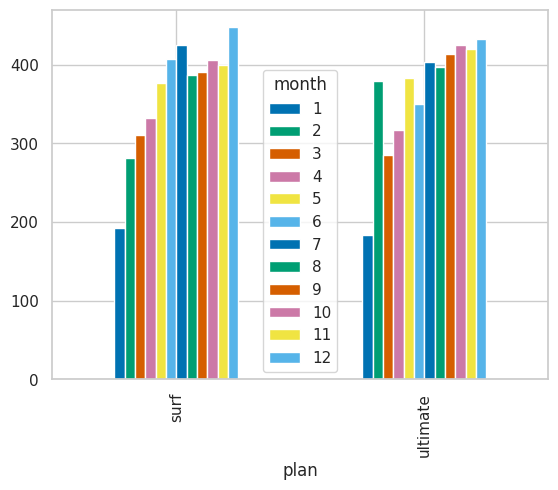

In [ ]:
full_data_per_user.groupby(['plan', 'month'])['total_minutes'].describe()['mean'].unstack().plot(kind='bar')

In [ ]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

full_data_per_user.groupby(['plan', 'month'])['total_minutes'].sum()

plan      month
surf      1           385.68
          2          2527.66
          3          7152.31
          4         16619.00
          5         29033.10
          6         39499.26
          7         51367.31
          8         62721.48
          9         75852.46
          10        96149.09
          11       113086.75
          12       142297.14
ultimate  1           732.65
          2          2659.03
          3          3428.42
          4          6646.67
          5         11126.28
          6         16441.12
          7         23822.27
          8         28206.51
          9         35542.71
          10        45067.81
          11        53400.65
          12        65384.90
Name: total_minutes, dtype: float64

<Axes: xlabel='plan'>

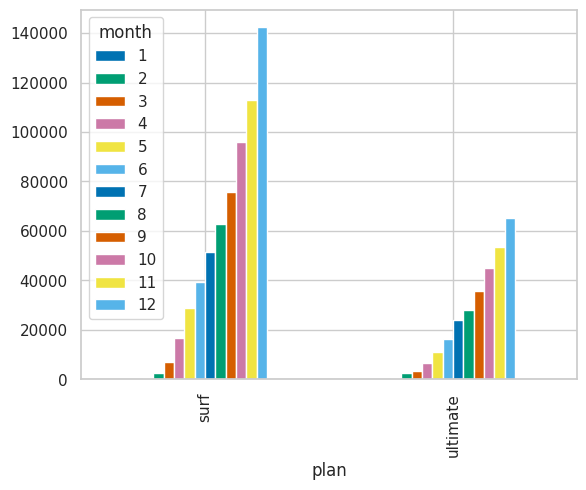

In [ ]:
# Consumo total de minutos por mes y plan, gráfico de barras

full_data_per_user.groupby(['plan', 'month'])['total_minutes'].sum().unstack().plot(kind='bar')

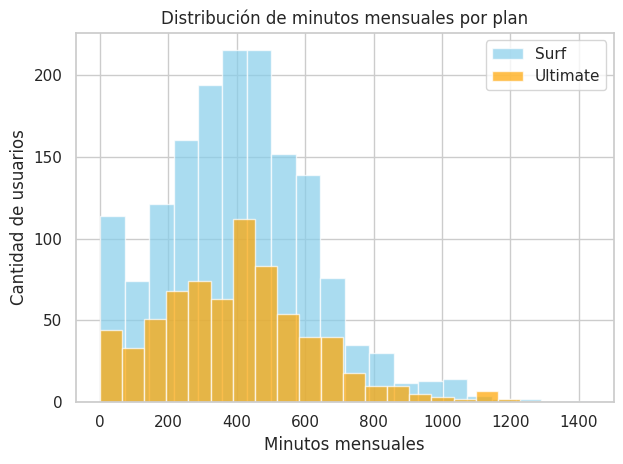

In [ ]:
# Histograma minutos mensuales que necesitan los usuarios de cada plan
# Los minutos ya están en el df full_data_per_user lo que quiere decir
# Que entra en el análisis el mes y el consumo mensual, por ende este histograma es válido

surf_minutes = full_data_per_user[full_data_per_user['plan'] == 'surf']['total_minutes']
ultimate_minutes = full_data_per_user[full_data_per_user['plan'] == 'ultimate']['total_minutes']

plt.hist(surf_minutes, bins=20, alpha=0.7, label='Surf', color='skyblue')
plt.hist(ultimate_minutes, bins=20, alpha=0.7, label='Ultimate', color='orange')

plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos mensuales')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calcula la media y la varianza de la duración mensual de llamadas.
# Método assign agrega una nueva columna al df, puede usar columnas del df u otros dfs

mean_std_var = full_data_per_user.groupby(['plan', 'month'])['total_minutes'].agg(['mean', 'std']).assign(variance=lambda df: df['std'] ** 2)
mean_std_var

mean         std      variance
plan     month                                      
surf     1      192.840000  121.636508  14795.440200
         2      280.851111  216.700761  46959.219961
         3      310.970000  178.385308  31821.317991
         4      332.380000  213.578245  45615.666796
         5      377.053247  230.830939  53282.922217
         6      407.208866  201.887744  40758.661193
         7      424.523223  233.311346  54434.184064
         8      387.169630  220.490503  48616.061790
         9      390.992062  203.912959  41580.494645
         10     405.692363  216.174537  46731.430317
         11     399.599823  214.720949  46105.085924
         12     447.475283  238.711641  56983.247423
ultimate 1      183.162500  122.439250  14991.369958
         2      379.861429  261.802002  68540.288348
         3      285.701667  232.967631  54273.917252
         4      316.508095  176.232027  31057.727496
         5      383.664828  198.218594  39290.610940
         6      349.811064  194.739212  37923.360514
         7      403.767288  254.645689  64844.426958
         8      397.274789  218.357939  47680.189425
         9      413.287326  225.819630  50994.505514
         10     425.168019  219.934586  48371.222127
         11     420.477559  232.948820  54265.152604
         12     433.012583  236.181535  55781.717507

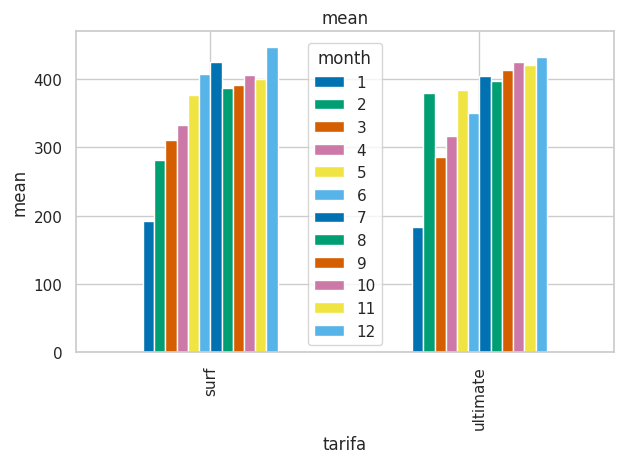

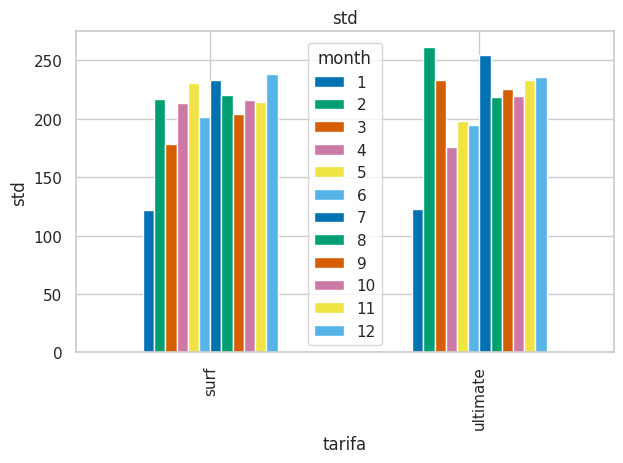

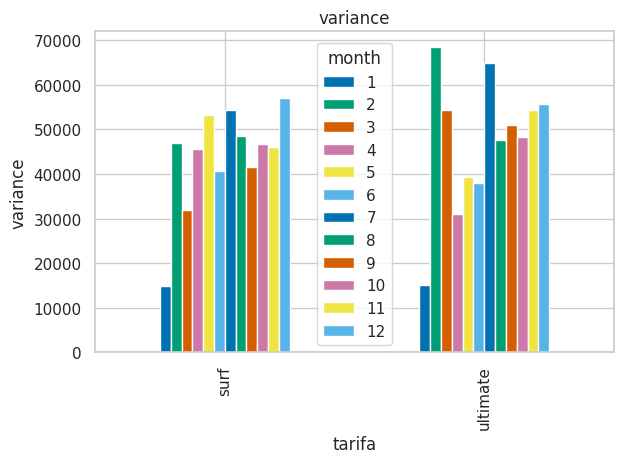

In [ ]:
for column in mean_std_var.columns:
    mean_std_var[column].unstack().plot(kind='bar', title=column)
    plt.ylabel(column)
    plt.xlabel('tarifa')
    plt.tight_layout()
    plt.show()

<ipython-input-63-a81a0a29399f>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


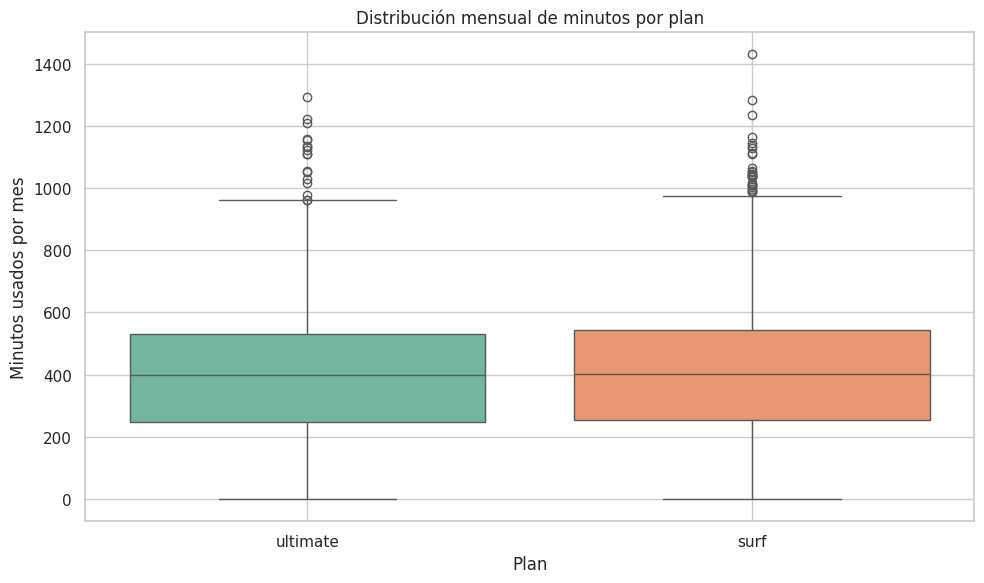

In [ ]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=full_data_per_user,
    x='plan',
    y='total_minutes',
    palette='Set2'
)

plt.title('Distribución mensual de minutos por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos usados por mes')
plt.grid(True)
plt.tight_layout()
plt.show()

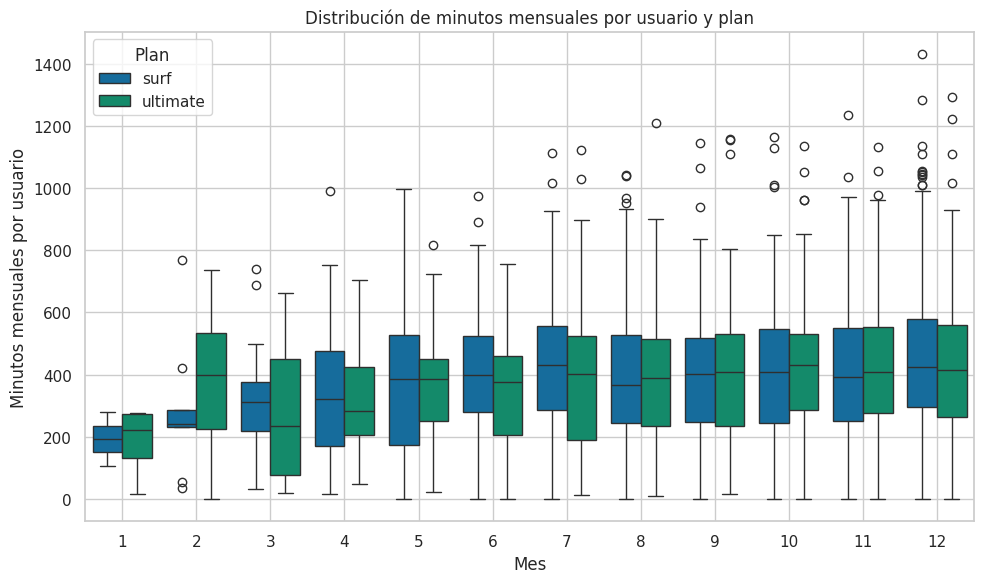

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=full_data_per_user, x='month', y='total_minutes', hue='plan')

plt.title('Distribución de minutos mensuales por usuario y plan')
plt.xlabel('Mes')
plt.ylabel('Minutos mensuales por usuario')
plt.legend(title='Plan')
plt.grid(True)
plt.tight_layout()
plt.show()



<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Lás gráficas demuestran comportamientos distintos según el plan, si bien los usuarios de plan ultimate tienen más minutos llaman menos que los usuarios del plan surf.

Esto se puede deber a que lo usuarios del plan surf son más que el ultimate lo cual causa un consumo mayor por parte de ese plan para todos los servicios.

</div>

### Mensajes

In [ ]:
# Compara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
full_data_per_user.groupby(['plan', 'month'])['messages_total'].sum()

plan      month
surf      1           21.0
          2          108.0
          3          351.0
          4          870.0
          5         1849.0
          6         2454.0
          7         3271.0
          8         4662.0
          9         5968.0
          10        8020.0
          11        9165.0
          12       12275.0
ultimate  1           62.0
          2          151.0
          3          243.0
          4          463.0
          5          931.0
          6         1379.0
          7         1937.0
          8         2732.0
          9         3259.0
          10        4181.0
          11        4903.0
          12        6796.0
Name: messages_total, dtype: float64

<Axes: xlabel='plan'>

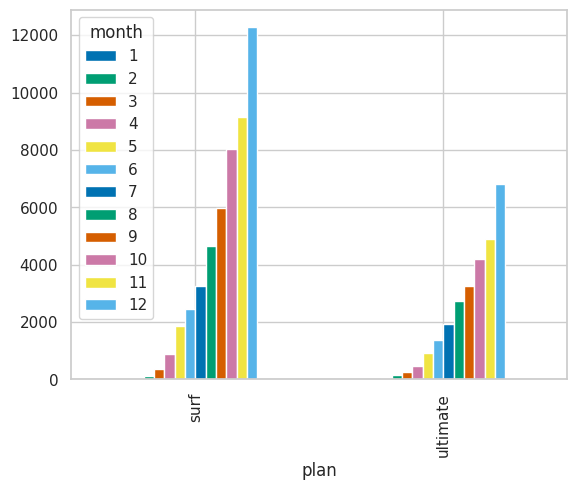

In [ ]:
full_data_per_user.groupby(['plan', 'month'])['messages_total'].sum().unstack().plot(kind='bar')

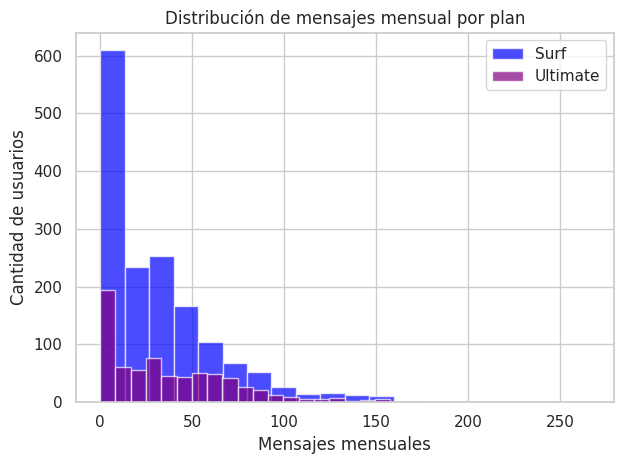

In [ ]:
surf_messages = full_data_per_user[full_data_per_user['plan'] == 'surf']['messages_total']
ultimate_messages = full_data_per_user[full_data_per_user['plan'] == 'ultimate']['messages_total']

plt.hist(surf_messages, bins=20, alpha=0.7, label='Surf', color='blue')
plt.hist(ultimate_messages, bins=20, alpha=0.7, label='Ultimate', color='purple')

plt.title('Distribución de mensajes mensual por plan')
plt.xlabel('Mensajes mensuales')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.tight_layout()
plt.show()

<ipython-input-68-e57c1e2a478a>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


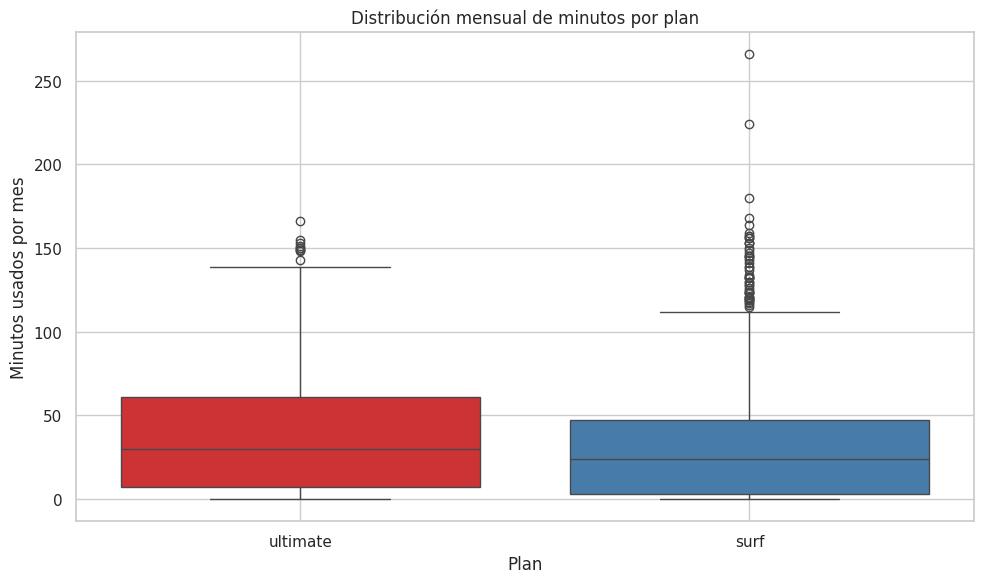

In [ ]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de mensajes

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=full_data_per_user,
    x='plan',
    y='messages_total',
    palette='Set1'
)

plt.title('Distribución mensual de minutos por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos usados por mes')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

full_data_per_user.groupby(['plan', 'month'])['mb_total'].sum()

plan      month
surf      1           9749.72
          2         109609.59
          3         306945.12
          4         599210.15
          5        1073099.33
          6        1484248.33
          7        2030815.67
          8        2720843.68
          9        3218737.67
          10       4102786.41
          11       4624009.00
          12       5766125.26
ultimate  1          27672.37
          2         119901.66
          3         219858.22
          4         338554.75
          5         482109.99
          6         720882.29
          7         964339.92
          8        1264845.13
          9        1459408.78
          10       1866930.66
          11       2163278.04
          12       2766801.97
Name: mb_total, dtype: float64

<Axes: xlabel='plan'>

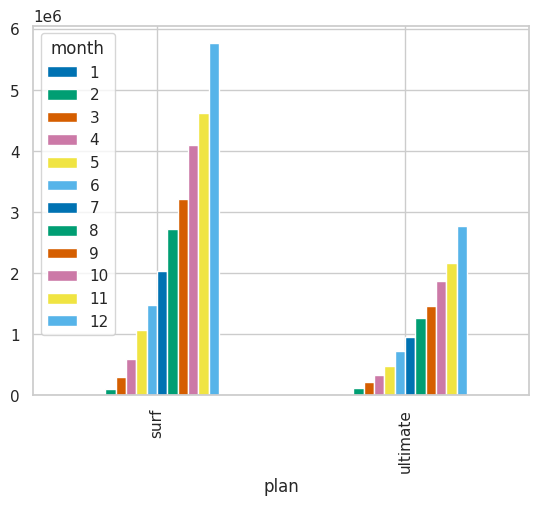

In [ ]:
full_data_per_user.groupby(['plan', 'month'])['mb_total'].sum().unstack().plot(kind='bar')

In [ ]:
full_data_per_user.groupby('plan')['mb_total'].describe()

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,16558.283490,8013.513327,0.0,11986.520,16829.31,20999.6100,70931.59
ultimate,720.0,17214.699694,7851.897435,0.0,12666.955,16858.34,21014.5275,46595.33


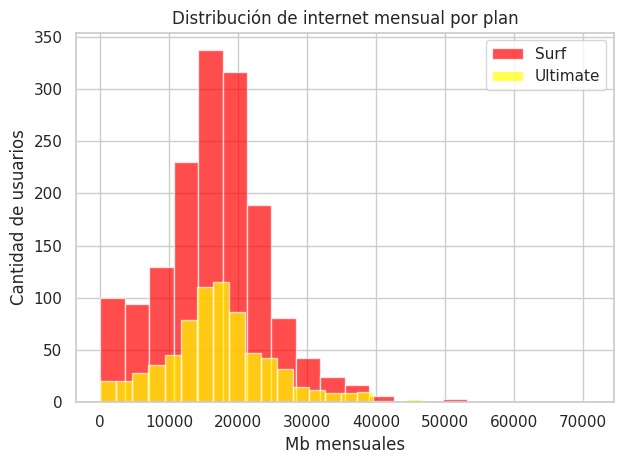

In [ ]:
surf_internet = full_data_per_user[full_data_per_user['plan'] == 'surf']['mb_total']
ultimate_internet = full_data_per_user[full_data_per_user['plan'] == 'ultimate']['mb_total']

plt.hist(surf_internet, bins=20, alpha=0.7, label='Surf', color='red')
plt.hist(ultimate_internet, bins=20, alpha=0.7, label='Ultimate', color='yellow')

plt.title('Distribución de internet mensual por plan')
plt.xlabel('Mb mensuales')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.tight_layout()
plt.show()



<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Lás gráficas demuestran comportamientos distintos según el plan, si bien los usuarios de plan ultimate tienen más minutos, más mensajes y más datos de navegación, llaman, navegan menos y mensajean menos que los usuarios del plan surf.

Esto se puede deber a que lo usuarios del plan surf son más que el ultimate lo cual causa un consumo mayor por parte de ese plan para todos los servicios.

</div>

### Internet

In [ ]:
full_data_per_user.groupby('plan')['mb_total'].describe()

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,16558.283490,8013.513327,0.0,11986.520,16829.31,20999.6100,70931.59
ultimate,720.0,17214.699694,7851.897435,0.0,12666.955,16858.34,21014.5275,46595.33


<ipython-input-74-dd13b951f6c9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


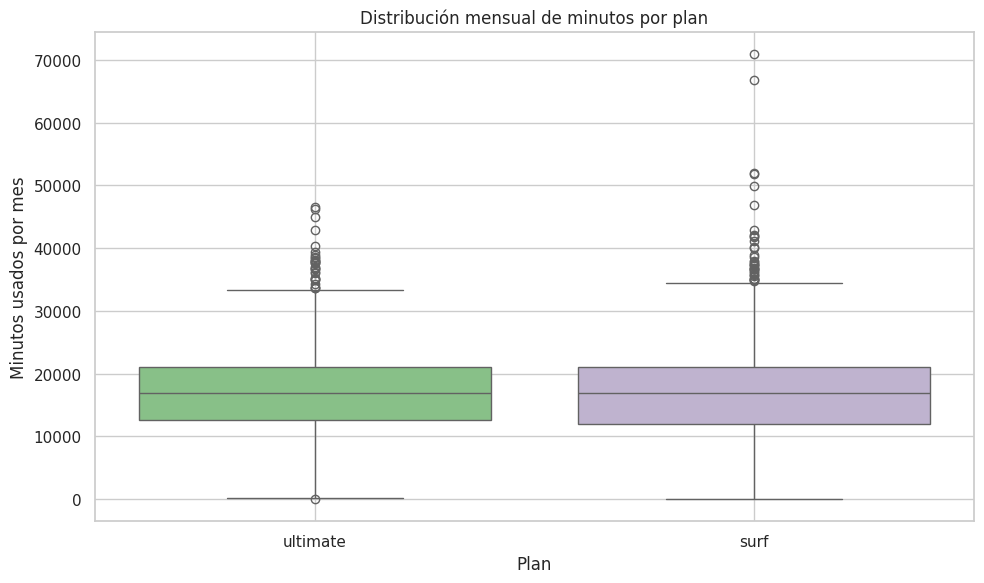

In [ ]:
# Traza un diagrama de caja para visualizar la distribución del uso de mb por parte de los usuarios

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=full_data_per_user,
    x='plan',
    y='mb_total',
    palette='Accent'
)

plt.title('Distribución mensual de minutos por plan')
plt.xlabel('Plan')
plt.ylabel('Minutos usados por mes')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# La idea con este filtrado es ver los consumos por plan, ciudad y grupo de edad así como el estado actual de afiliación con el operador.

consuption_due_plan_city_age = full_data_per_user.groupby(['plan','city', 'age_group'])[
    ['calls_total',	'total_minutes',	'messages_total',	'mb_total','estatus: active']
    ].sum().sort_values(by='estatus: active', ascending=False)

# Esta línea agrupa por plan debido a que la anterior mezcla las instancias
# Cuando se usa sort_values() sobre un groupby multinivel ordena toda la tabla globalmente sin respetar los grupos por 'plan'.

consuption_due_plan_city_age = consuption_due_plan_city_age.groupby(
    level='plan', group_keys=True).apply(lambda x: x.sort_values(by='estatus: active', ascending=False))

consuption_due_plan_city_age

<ipython-input-75-4fa36196dbe7>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  consuption_due_plan_city_age = full_data_per_user.groupby(['plan','city', 'age_group'])[


calls_total  \
plan     plan     city                                      age_group                   
surf     surf     New York-Newark-Jersey City, NY-NJ-PA MSA Adulto             7982.0   
                                                            Adulto joven       4583.0   
                                                            Senior             4205.0   
                  Dallas-Fort Worth-Arlington, TX MSA       Adulto             2343.0   
                  Seattle-Tacoma-Bellevue, WA MSA           Adulto joven       2183.0   
...                                                                               ...   
ultimate ultimate Boston-Cambridge-Newton, MA-NH MSA        Senior                0.0   
                  Austin-Round Rock-Georgetown, TX MSA      Adulto                0.0   
                  Atlanta-Sandy Springs-Roswell, GA MSA     Adulto joven          0.0   
                  Albuquerque, NM MSA                       Senior                0.0   
                  Baltimore-Columbia-Towson, MD MSA         Senior                0.0   

                                                                          total_minutes  \
plan     plan     city                                      age_group                     
surf     surf     New York-Newark-Jersey City, NY-NJ-PA MSA Adulto             54538.22   
                                                            Adulto joven       31347.90   
                                                            Senior             28795.22   
                  Dallas-Fort Worth-Arlington, TX MSA       Adulto             16080.38   
                  Seattle-Tacoma-Bellevue, WA MSA           Adulto joven       14539.56   
...                                                                                 ...   
ultimate ultimate Boston-Cambridge-Newton, MA-NH MSA        Senior                 0.00   
                  Austin-Round Rock-Georgetown, TX MSA      Adulto                 0.00   
                  Atlanta-Sandy Springs-Roswell, GA MSA     Adulto joven           0.00   
                  Albuquerque, NM MSA                       Senior                 0.00   
                  Baltimore-Columbia-Towson, MD MSA         Senior                 0.00   

                                                                          messages_total  \
plan     plan     city                                      age_group                      
surf     surf     New York-Newark-Jersey City, NY-NJ-PA MSA Adulto                3016.0   
                                                            Adulto joven          1301.0   
                                                            Senior                1795.0   
                  Dallas-Fort Worth-Arlington, TX MSA       Adulto                 759.0   
                  Seattle-Tacoma-Bellevue, WA MSA           Adulto joven           879.0   
...                                                                                  ...   
ultimate ultimate Boston-Cambridge-Newton, MA-NH MSA        Senior                   0.0   
                  Austin-Round Rock-Georgetown, TX MSA      Adulto                   0.0   
                  Atlanta-Sandy Springs-Roswell, GA MSA     Adulto joven             0.0   
                  Albuquerque, NM MSA                       Senior                   0.0   
                  Baltimore-Columbia-Towson, MD MSA         Senior                   0.0   

                                                                            mb_total  \
plan     plan     city                                      age_group                  
surf     surf     New York-Newark-Jersey City, NY-NJ-PA MSA Adulto        2228138.95   
                                                            Adulto joven  1302247.91   
                                                            Senior        1097122.93   
                  Dallas-Fort Worth-Arlington, TX MSA       Adulto         888186.35   
       

<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
El anterior df nos da una idea clara del consumo en ciudades por grupo de edad y plan, se puede verificar el comportamiento de consumo con estas variables

</div>

In [ ]:
grouped_by_plan_age = full_data_per_user.groupby(['plan', 'age_group'])[
    ['calls_total', 'total_minutes', 'messages_total', 'mb_total']
].sum()

grouped_by_plan_age # Suma los valores y da un total de consumo

<ipython-input-76-dbcd512b21e8>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_by_plan_age = full_data_per_user.groupby(['plan', 'age_group'])[


calls_total  total_minutes  messages_total    mb_total
plan     age_group                                                           
surf     Adulto            29684.0      202567.01         16590.0  8658626.41
         Adulto joven      25042.0      169366.66         12432.0  7304039.39
         Joven             14725.0       99424.89          7888.0  3406336.82
         Senior            24633.0      165332.68         12104.0  6677177.31
ultimate Adulto            14419.0       96605.89          7828.0  4531036.48
         Adulto joven       9226.0       62284.72          7339.0  2814559.36
         Joven              5876.0       39436.45          3423.0  1503439.64
         Senior            14130.0       94131.96          8447.0  3545548.30

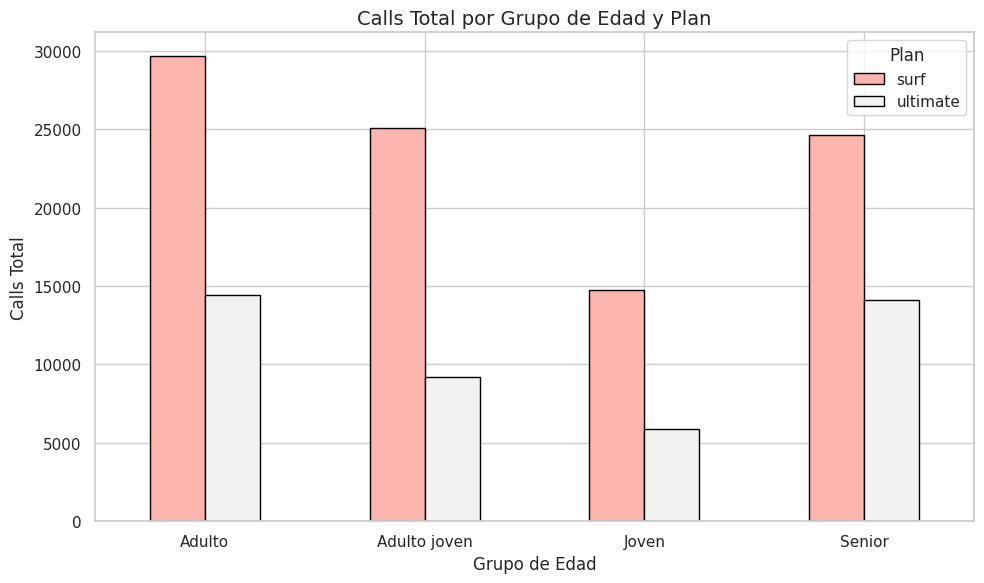

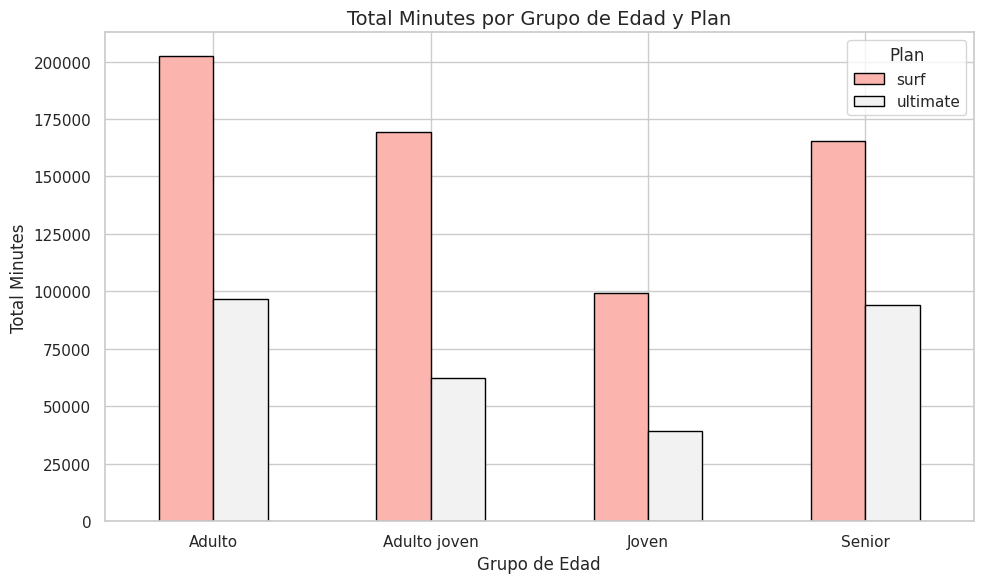

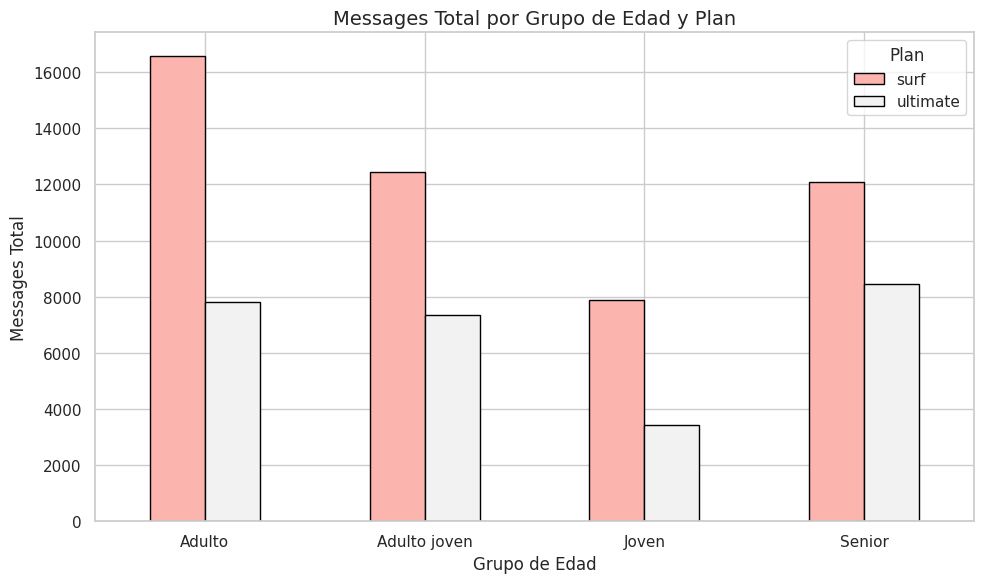

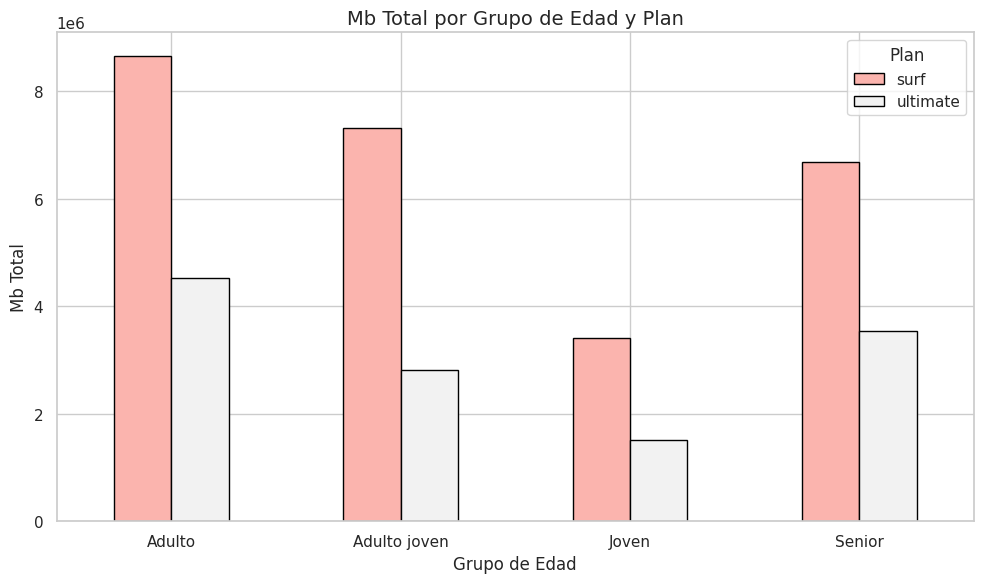

In [ ]:
# Lista de variables que vamos a graficar
variables = grouped_by_plan_age.columns


# Generar una gráfica de barras por variable
for var in variables:
    # Reorganizamos los datos para tener los planes como columnas
    data = grouped_by_plan_age[var].unstack(level=0)

    # Hacemos la gráfica
    ax = data.plot(
        kind='bar',
        figsize=(10, 6),
        edgecolor='black',
        colormap='Pastel1'
    )

    ax.set_title(f'{var.replace("_", " ").title()} por Grupo de Edad y Plan', fontsize=14)
    ax.set_xlabel('Grupo de Edad')
    ax.set_ylabel(var.replace("_", " ").title())
    ax.legend(title='Plan')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
El comportamiento de consumo NO depende de la edad, todo los grupos generacionales suelen tener hábitos de consumo muy parecidos

</div>

In [ ]:
grouped = full_data_per_user.groupby(['plan', 'age_group'])[
    ['calls_total', 'total_minutes', 'messages_total', 'mb_total']
]

avg_consumption_per_age = grouped.sum() / grouped.count()  # Se busca el promedio de cada variable y así tener un panorama de consumo

avg_consumption_per_age = avg_consumption_per_age.rename(columns={
    'calls_total': 'avg_calls',
    'total_minutes': 'avg_minutes',
    'messages_total': 'avg_messages',
    'mb_total': 'avg_mb'
})

avg_consumption_per_age

<ipython-input-78-307db78e23d0>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = full_data_per_user.groupby(['plan', 'age_group'])[


avg_calls  avg_minutes  avg_messages        avg_mb
plan     age_group                                                       
surf     Adulto        56.757170   387.317419     31.720841  16555.691033
         Adulto joven  56.274157   380.599236     27.937079  16413.571663
         Joven         69.457547   468.985330     37.207547  16067.626509
         Senior        62.679389   420.693842     30.798982  16990.273053
ultimate Adulto        57.676000   386.423560     31.312000  18124.145920
         Adulto joven  56.601227   382.114847     45.024540  17267.235337
         Joven         66.772727   448.141477     38.897727  17084.541364
         Senior        64.520548   429.826301     38.570776  16189.718265

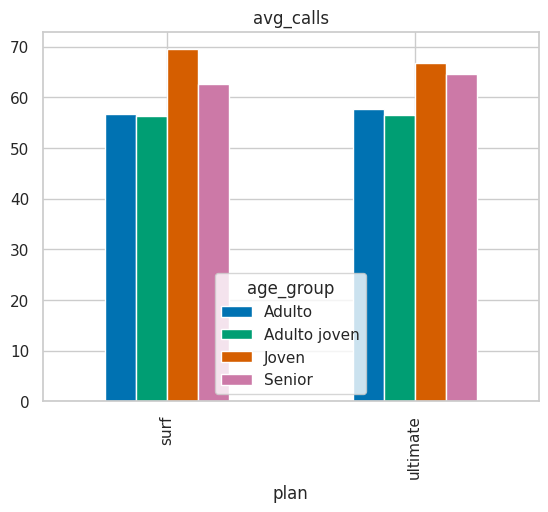

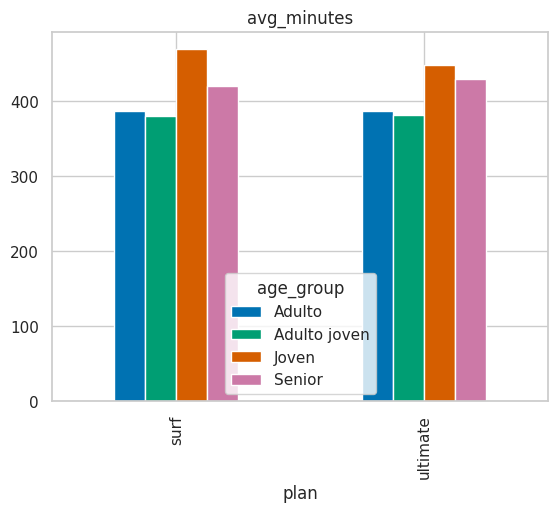

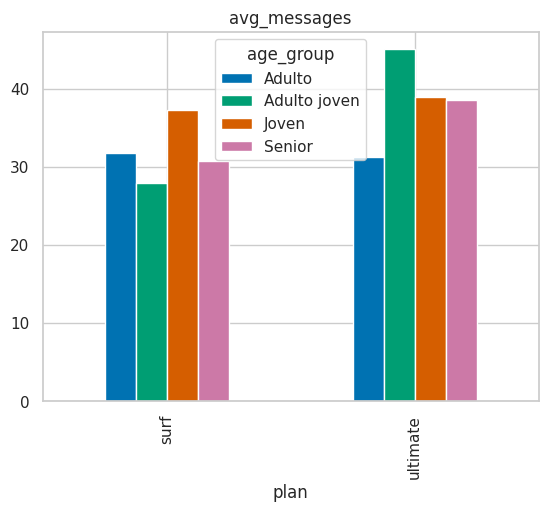

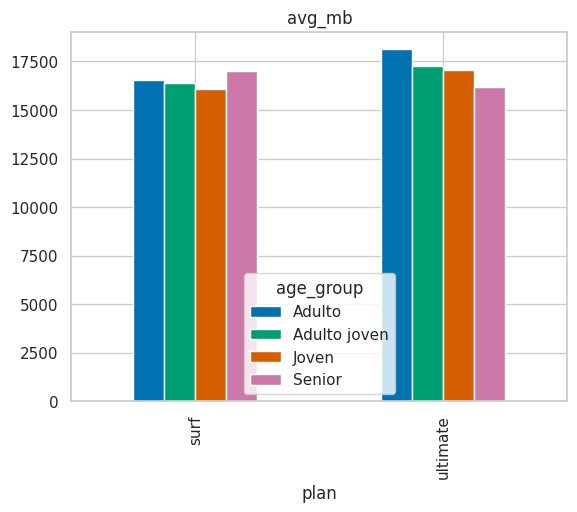

In [ ]:
for column in avg_consumption_per_age.columns: # Se grafican para ver los valores más visualmente
    avg_consumption_per_age[column].unstack().plot(kind='bar', title=column)

<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
La gráficas anteriores junto con dfs nos dan una idea exacta del consumo según edad, si bien uno esperaria que los jovenes consuman más en promedio todos los servicios se verifica y se nota que es una tendencia global, es decir, los 4 grupos generacionales definidos consumen servicios de telefonía de manera similar.

</div>

In [ ]:
full_data_per_user.groupby(['plan'])['estatus: active'].sum()

,estatus: active
plan,
surf,1467
ultimate,668


<Axes: xlabel='plan'>

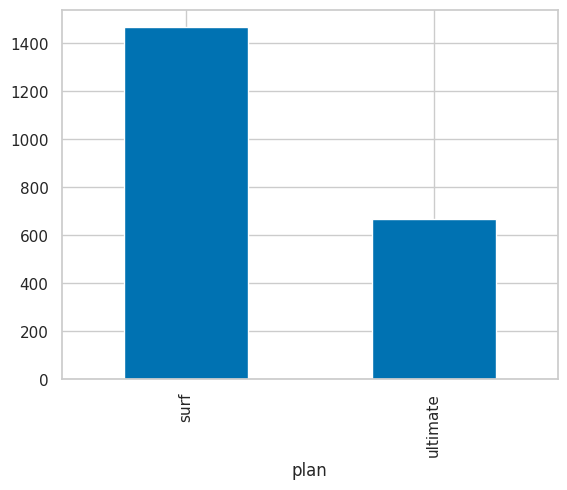

In [ ]:
full_data_per_user.groupby(['plan'])['estatus: active'].sum().plot(kind='bar')

<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
La gráficas anteriores junto con dfs se realizaron con el ánimo de verificar las cantidades de usuarios activos de cada plan
</div>

In [ ]:
# Se filtra para saber cual es la ciudad que más consume servicios mensualmente por plan
# Es mensual porque la tabla original tiene en cuenta cada cosumo de usuario por un més específico

full_data_per_user.groupby(['plan', 'city'])['city'].count().sort_values(ascending=False)

plan      city                                          
surf      New York-Newark-Jersey City, NY-NJ-PA MSA         312
          Los Angeles-Long Beach-Anaheim, CA MSA             81
          Dallas-Fort Worth-Arlington, TX MSA                75
          Boston-Cambridge-Newton, MA-NH MSA                 65
ultimate  New York-Newark-Jersey City, NY-NJ-PA MSA          65
                                                           ... 
surf      Virginia Beach-Norfolk-Newport News, VA-NC MSA      2
ultimate  Cape Coral-Fort Myers, FL MSA                       1
surf      Tucson, AZ MSA                                      1
ultimate  Austin-Round Rock-Georgetown, TX MSA                1
          Bakersfield, CA MSA                                 1
Name: city, Length: 122, dtype: int64

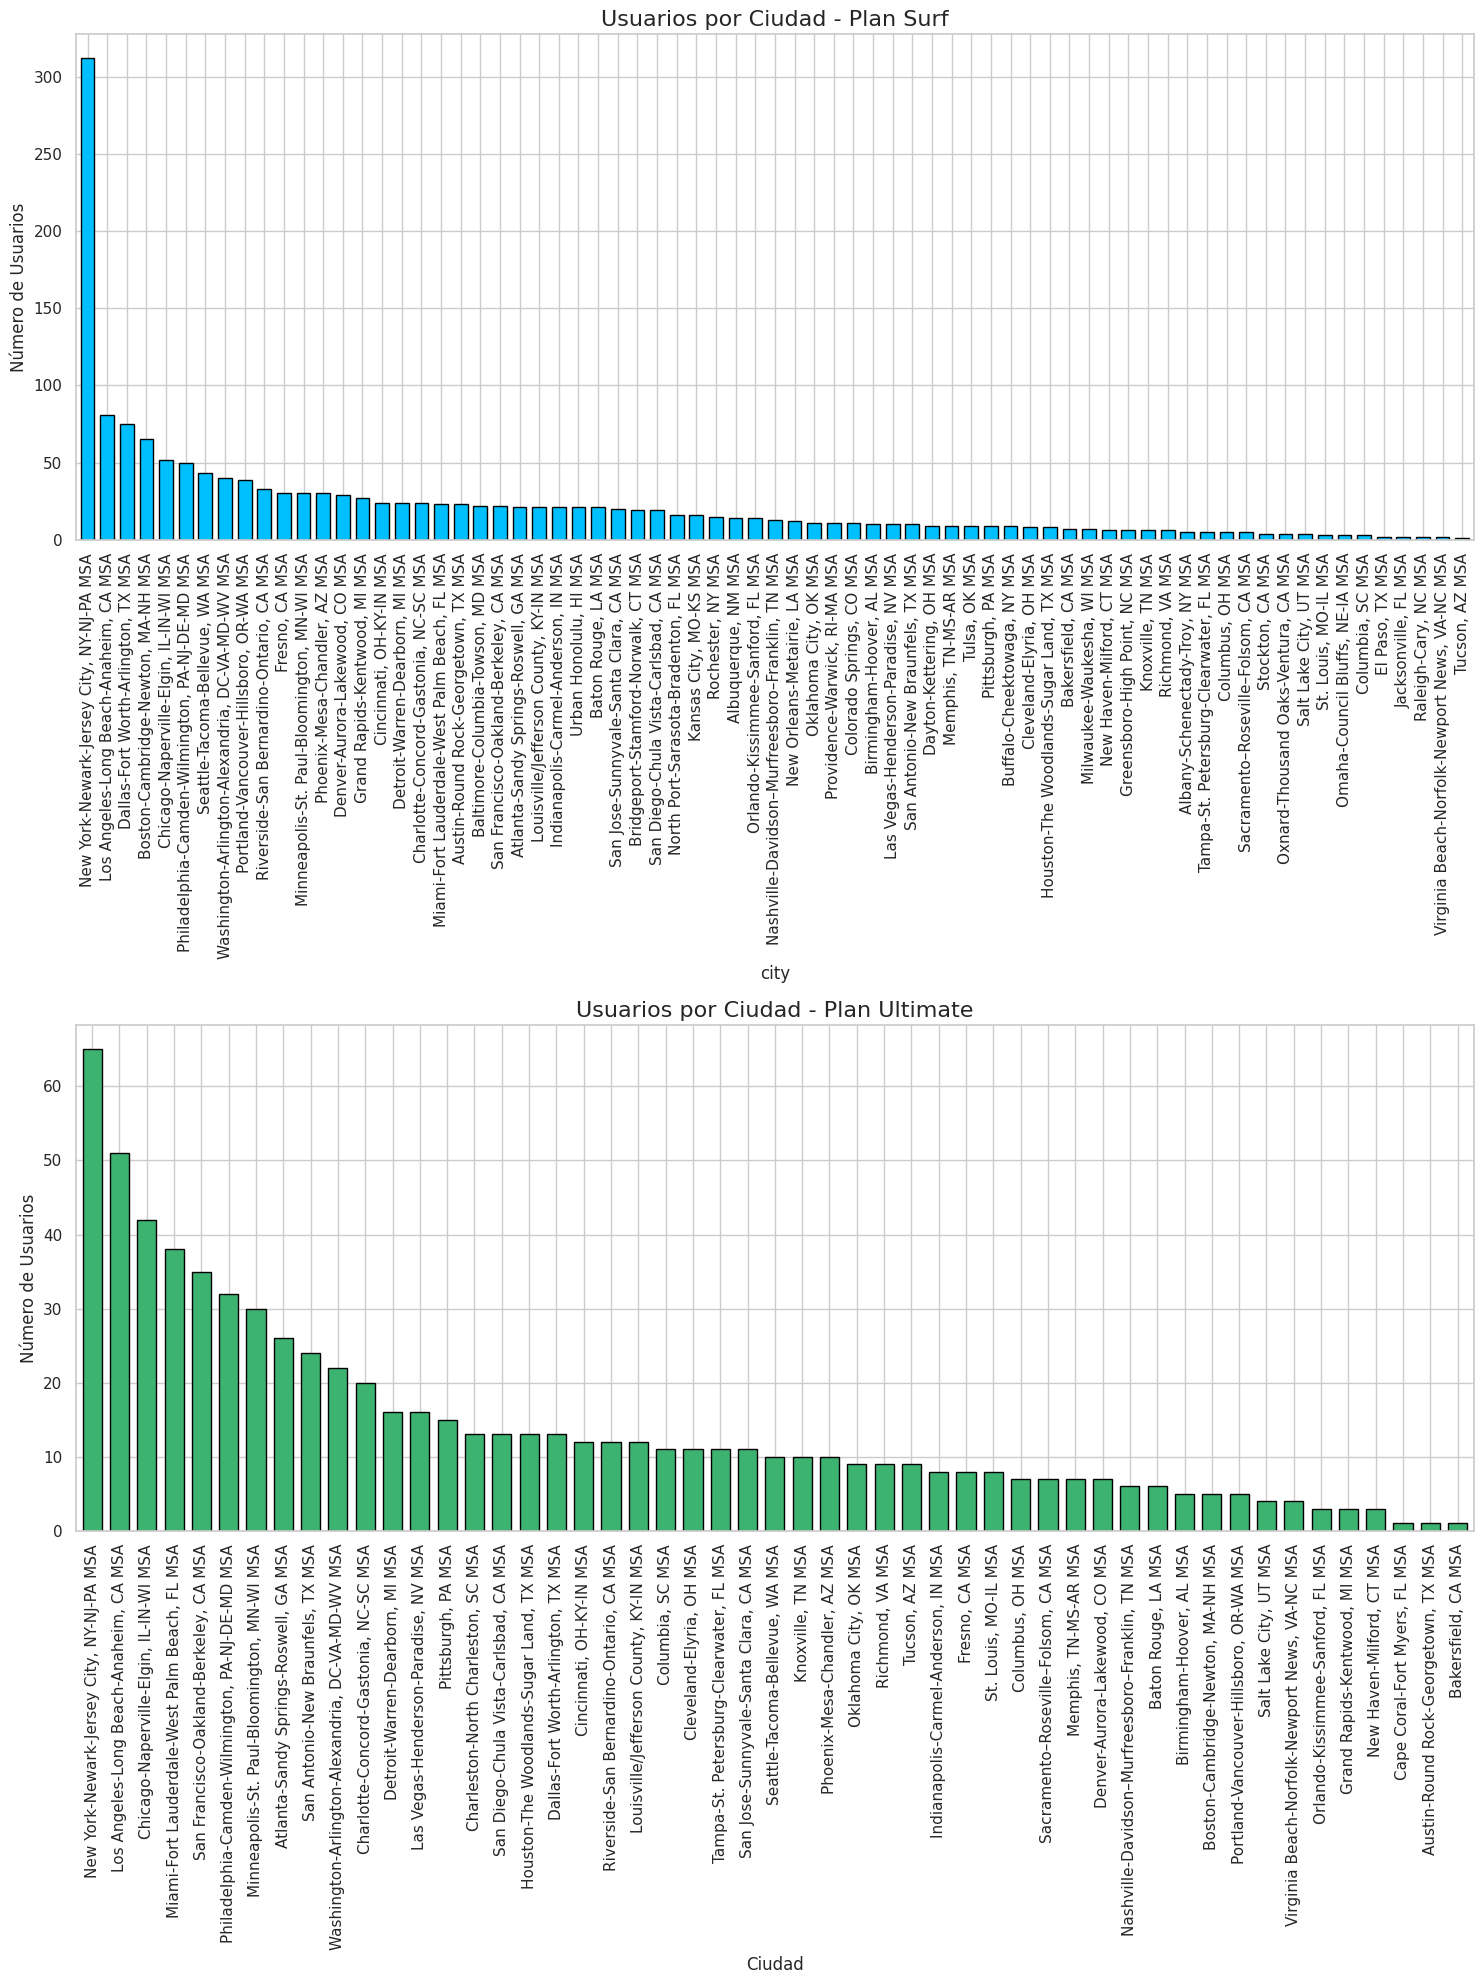

In [ ]:
# Filtra los datos por plan
surf_data = full_data_per_user[full_data_per_user['plan'] == 'surf']
ultimate_data = full_data_per_user[full_data_per_user['plan'] == 'ultimate']

# Agrupa y ordena
surf_counts = surf_data.groupby('city')['city'].count().sort_values(ascending=False)
ultimate_counts = ultimate_data.groupby('city')['city'].count().sort_values(ascending=False)

# Crear gráfico
fig, axes = plt.subplots(2, 1, figsize=(15, 20))  # Más alto y más ancho

# Gráfico Surf
surf_counts.plot(
    kind='bar',
    ax=axes[0],
    color='deepskyblue',
    edgecolor='black',
    width=0.7
)
axes[0].set_title('Usuarios por Ciudad - Plan Surf', fontsize=16)
axes[0].set_ylabel('Número de Usuarios')
axes[0].tick_params(axis='x', labelrotation=90)

# Gráfico Ultimate
ultimate_counts.plot(
    kind='bar',
    ax=axes[1],
    color='mediumseagreen',
    edgecolor='black',
    width=0.7
)
axes[1].set_title('Usuarios por Ciudad - Plan Ultimate', fontsize=16)
axes[1].set_xlabel('Ciudad')
axes[1].set_ylabel('Número de Usuarios')
axes[1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()




<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
En esta sección del análisis, se exploró el comportamiento de los usuarios en función de su plan de servicio, ciudad y grupo generacional. Primero, se analizaron las distribuciones del consumo de datos (MB) mediante diagramas de caja para detectar posibles diferencias entre planes. Luego, se agruparon y ordenaron los consumos totales (llamadas, minutos, mensajes y datos) por ciudad y edad, segmentados por plan, permitiendo identificar patrones locales y generacionales. A pesar de segmentar el consumo por edad, los resultados muestran que no existen diferencias significativas entre los distintos grupos generacionales: todos presentan hábitos de consumo bastante similares. Además, al visualizar el promedio de consumo mensual, se confirmó esta homogeneidad generacional. Por otra parte, se identificó que el plan más popular entre los usuarios es el plan Surf, y que la ciudad con mayor concentración de clientes es Nueva York, lo que puede tener implicaciones clave para estrategias comerciales y de infraestructura. Las gráficas por plan y ciudad, realizadas de forma clara y segmentada, permiten visualizar estas tendencias de forma intuitiva, reafirmando que el consumo no varía drásticamente según la edad, pero sí según la ciudad y el tipo de plan contratado.

</div>

## Ingreso

In [ ]:
len(full_data_per_user['full_name'].unique())

490

In [ ]:
# Se saca muestra pa ver el comportamiento de un usuario
# Se evidencia que su total gastado durante el mes de diciembre fue de 588 dólares
full_data_per_user[full_data_per_user['full_name'] == 'Jarrett Spencer']

,user_id,full_name,plan,age,age_group,city,estatus: active,calls_total,total_minutes,messages_total,mb_total,avg_session_mb,days_active,reg_date,month,monthly_revenue_&_extra
1755,1379,Jarrett Spencer,surf,34,Adulto joven,"Grand Rapids-Kentwood, MI MSA",True,36.0,243.92,28.0,17772.30,522.714706,2424,2018-10-18,11,50.0000
1756,1379,Jarrett Spencer,surf,34,Adulto joven,"Grand Rapids-Kentwood, MI MSA",True,144.0,1045.24,126.0,70931.59,537.360530,2424,2018-10-18,12,588.6372


In [ ]:
# Se crea este filtrado con la idea de ver los usuarios que más han gastado en su tarifa
# Los valores extra son bastante elevados lo que indica que la gente usa más servicios que los de los ofertados por la compañia
# En sus planes iniciales

plan_name = full_data_per_user.groupby(['plan', 'full_name','month'])['monthly_revenue_&_extra'].sum().sort_values(ascending=False).head(100)

plan_name_revenue = plan_name.groupby(
    level='plan', group_keys=True).apply(lambda x: x.sort_values(ascending=False)) # Me acomoda el sort por monthly_revenue_&_extra sin mover el plan

plan_name_revenue

plan      plan      full_name           month
surf      surf      Jarrett Spencer     12       588.6372
                    Kathaleen Albert    12       531.4100
                    Cassey French       8        380.0000
                                        12       380.0000
                    Drema Lopez         8        376.1664
                                                   ...   
                    Reynaldo Jenkins    12       156.2300
                    Olin Adkins         11       155.0640
ultimate  ultimate  Jefferey Rasmussen  10       182.0000
                    Shane Cortez        12       182.0000
                    Olympia Velazquez   12       168.0000
Name: monthly_revenue_&_extra, Length: 100, dtype: float64

In [ ]:
# Se reacomoda la tabla con unstack() y me quedan los revenues totales de cada usuario por mes dependiendo del tipo de plan

revenue_by_user_month = full_data_per_user.groupby(['plan', 'full_name','month'])['monthly_revenue_&_extra'].sum().unstack().fillna(0)
revenue_by_user_month

month                        1     2     3      4      5     6     7     8   \
plan     full_name                                                            
surf     Aaron Rowe         0.0   0.0   0.0    0.0    0.0   0.0   0.0  20.0   
         Abraham Mcconnell  0.0   0.0   0.0  100.0  100.0  90.0  90.0  60.0   
         Adelle Knapp       0.0   0.0   0.0    0.0    0.0   0.0   0.0   0.0   
         Al Rasmussen       0.0   0.0   0.0    0.0    0.0   0.0   0.0   0.0   
         Alaine Robertson   0.0  20.0  40.0   20.0   20.0  40.0  20.0  50.0   
...                         ...   ...   ...    ...    ...   ...   ...   ...   
ultimate Weston Conley      0.0   0.0   0.0    0.0    0.0   0.0   0.0   0.0   
         Winford Underwood  0.0   0.0   0.0    0.0   70.0  91.0  70.0  70.0   
         Yuk French         0.0   0.0   0.0    0.0    0.0   0.0   0.0   0.0   
         Zack Waters        0.0   0.0   0.0    0.0   70.0  70.0  70.0  70.0   
         Zofia Brock        0.0   0.0   0.0    0.0   70.0  70.0  70.0  70.0   

month                           9         10        11        12  
plan     full_name                                                
surf     Aaron Rowe          60.00   40.4200  120.0000   90.6900  
         Abraham Mcconnell  150.09   50.0000   80.0000   60.1500  
         Adelle Knapp        60.12  191.8056  226.0819  229.6935  
         Al Rasmussen         0.00    0.0000   20.0000  115.0655  
         Alaine Robertson    40.00   20.7902   20.0000   20.0000  
...                            ...       ...       ...       ...  
ultimate Weston Conley        0.00   70.0000   70.0000   70.0000  
         Winford Underwood  105.00   70.0000   70.0000   77.0000  
         Yuk French           0.00    0.0000    0.0000   70.0000  
         Zack Waters         70.00   70.0000   70.0000   70.0000  
         Zofia Brock         70.00   70.0000   70.0000   70.0000  

[490 rows x 12 columns]

In [ ]:
# Se filtra el mismo ejemplo anterior para visualizaro

Jarrett_Spencer = revenue_by_user_month.reset_index()
Jarrett_Spencer[Jarrett_Spencer['full_name'] == 'Jarrett Spencer']

month,plan,full_name,1,2,3,4,5,6,7,8,9,10,11,12
142,surf,Jarrett Spencer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,588.6372


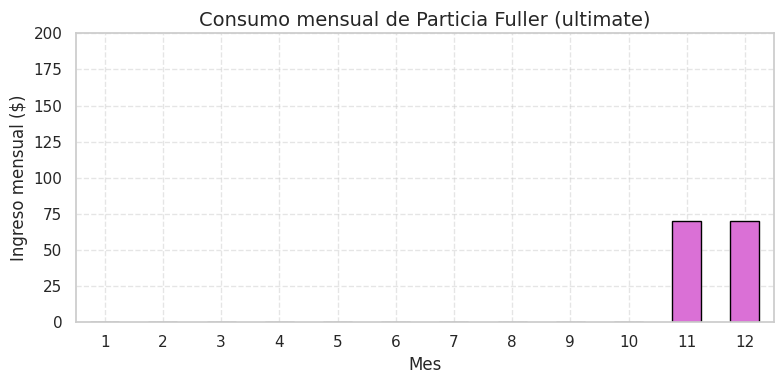

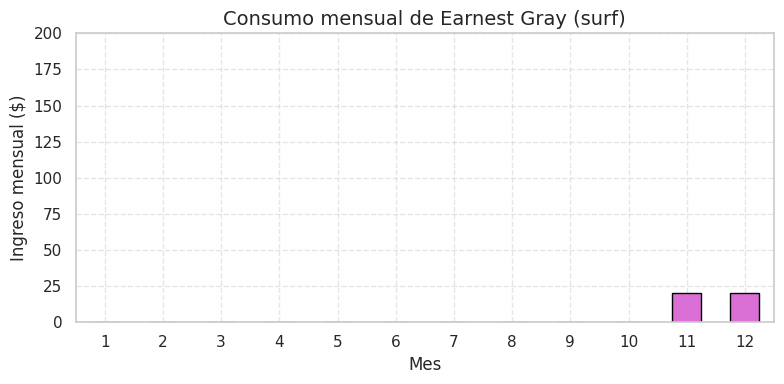

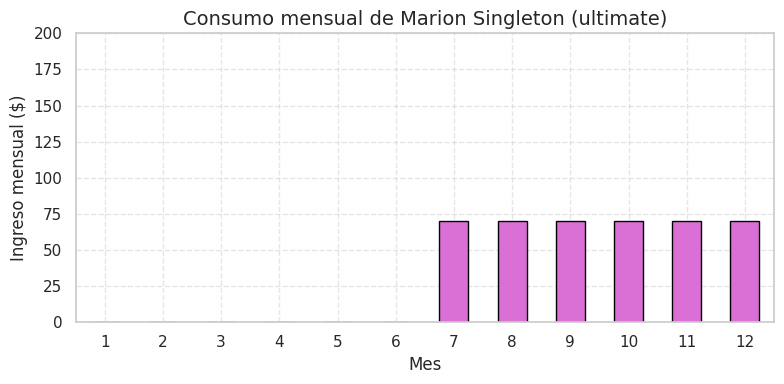

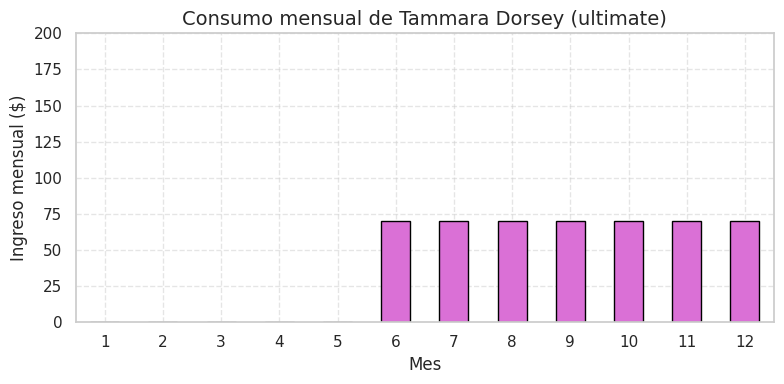

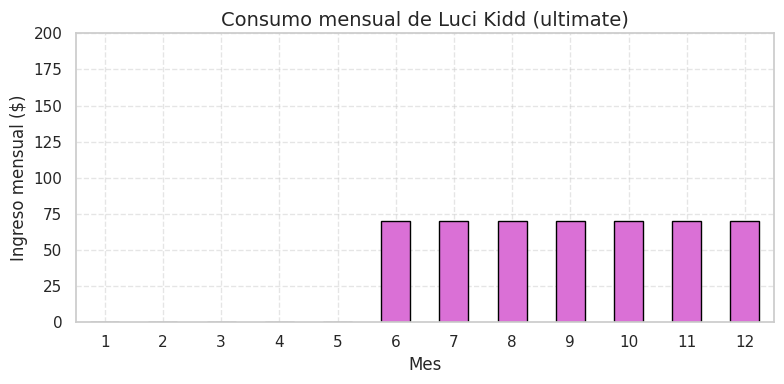

In [ ]:
# Se gráfica una muestra aleatoria de 5 usuarios para ver sus consumos mensuales en el año correspondiente

# Tomar 5 usuarios aleatorios del índice
muestras = revenue_by_user_month.sample(5, random_state=42)  # Puedes cambiar el random_state o quitarlo

# Graficar el consumo mensual por usuario
for idx, fila in muestras.iterrows():
    nombre_usuario = idx[1]  # idx es una tupla: (plan, full_name)
    plan_usuario = idx[0]

    plt.figure(figsize=(8, 4))
    fila.plot(kind='bar', color='orchid', edgecolor='black')  # Rosado suave

    plt.title(f'Consumo mensual de {nombre_usuario} ({plan_usuario})', fontsize=14)
    plt.xlabel('Mes')
    plt.ylabel('Ingreso mensual ($)')
    plt.ylim(0, 200)
    plt.xticks(rotation=0)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Si bien NO se extrajo la información directa de cuantos mb, llamadas y mensajes extra hicieron los usuarios para añadirlos al df si se tuvieron en cuenta a la hora de calcular la columna monthly_revenue_&_extra, que contiene la tarifa fija y si es el caso el cobro de consumo extra, al analizar el df se deja ver que los planes:

1. Son pequeños en comparación con los ofertados por la compañía.
2. Se podrían buscar oportunidades comerciales con servicios incluidos y promociones.
3. Los usuarios de plan ultimate no son necesariamente los que más gastan aun así su plan sea más caro.
4. En unos 5 años según las tendencias del mercado las personas consumirán mucho más.

</div>

In [ ]:
# Se verifica el describe de la columna de costos para ver sus valores máximos y minimos
# Como se habia dicho antes, los usuarios que más gastan suelen ser los surf aunque su plan sea más barato
full_data_per_user.groupby(['plan'])['monthly_revenue_&_extra'].describe()

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,60.327346,55.262605,20.0,20.0,40.15,80.0,588.6372
ultimate,720.0,72.313889,11.395108,70.0,70.0,70.00,70.0,182.0000


In [ ]:
full_data_per_user.groupby(['plan', 'month'])['monthly_revenue_&_extra'].sum()

plan      month
surf      1           40.0000
          2          308.3106
          3         1053.1760
          4         2022.7350
          5         3637.1069
          6         4746.2813
          7         7528.8550
          8        10298.7550
          9        11242.0168
          10       15416.0702
          11       16308.9542
          12       22292.6546
ultimate  1          280.0000
          2          490.0000
          3          896.0000
          4         1533.0000
          5         2051.0000
          6         3367.0000
          7         4242.0000
          8         5173.0000
          9         6195.0000
          10        7665.0000
          11        9107.0000
          12       11067.0000
Name: monthly_revenue_&_extra, dtype: float64

<Axes: xlabel='plan'>

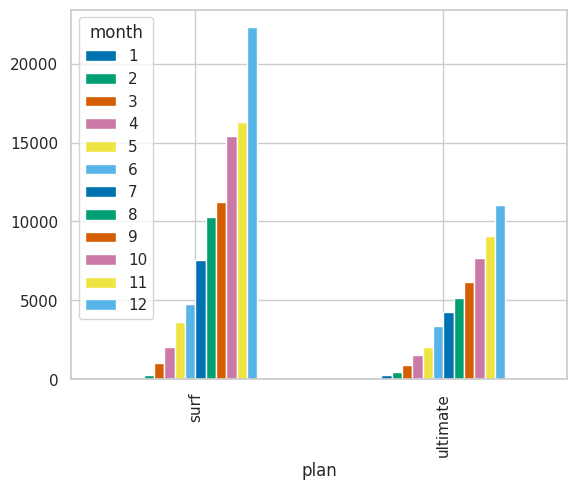

In [ ]:
full_data_per_user.groupby(['plan', 'month'])['monthly_revenue_&_extra'].sum().unstack().plot(kind='bar')

In [ ]:
# Se revisa el income total por cad plan en el año
# Acá se buscala diferencia en income teniendo como base el income del plan ultimate
# Por el plan surf la empresa recibe un 82 % más de dinero

surf_total_income = full_data_per_user[full_data_per_user['plan'] == 'surf']['monthly_revenue_&_extra'].sum()
ultimate_total_income = full_data_per_user[full_data_per_user['plan'] == 'ultimate']['monthly_revenue_&_extra'].sum()

diferences_in_income = ((surf_total_income - ultimate_total_income)/ultimate_total_income)*100
print(diferences_in_income)

82.25889371182731


<Axes: xlabel='plan'>

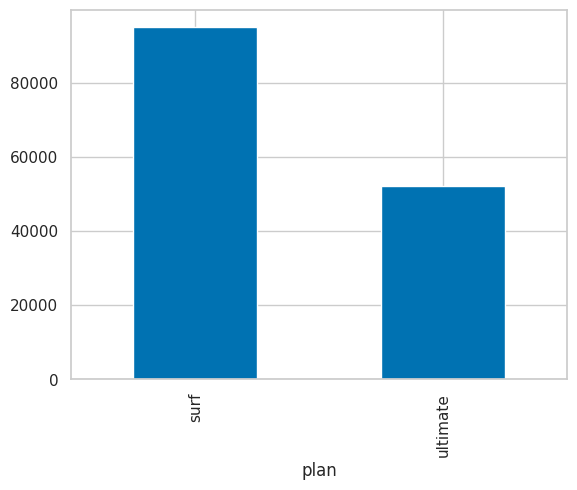

In [ ]:
# Según la gráfica la empresa recibe un 82 % más de dinero por el plan surf

full_data_per_user.groupby('plan')['monthly_revenue_&_extra'].sum().plot(kind='bar')


<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Es claro que la empresa recibe mucho más por los usuarios del plan surf no solo porque son más usuarios sino porque es un plan que cobra más caro el extra y ofrece menos cantidad de covertura de servicios se evidencia que muchos usuarios sobrepasan lo ofrecido por el plan e incurren en costos extras, sin embargo el promedio de pago de los usuarios de ultimate es más alto siendo de 72.313889 dólares y el de surf es de 60.327346 dolares.

El plan surf vale 20 dólares al mes, en promedio sus usuarios pagan 40.3 dólares extra mientras que los usuarios de ultimate solo pagan en promedio 2.31 dólares.

La relación calidad precio de ultimate es mucho mejor que la de surf.

</div>

## Prueba las hipótesis estadísticas



<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Hipótesis nula (H₀):
No hay diferencia en los ingresos promedio entre los usuarios del plan Surf y Ultimate.

H₀: μ₁ = μ₂

Hipótesis alternativa (H₁):
Sí hay una diferencia en los ingresos promedio entre los usuarios de los dos planes.

H₁: μ₁ ≠ μ₂

</div>

In [ ]:
# Prueba las hipótesis

# Filtrar ingresos por plan
surf_income = full_data_per_user[full_data_per_user['plan'] == 'surf']['monthly_revenue_&_extra']
ultimate_income = full_data_per_user[full_data_per_user['plan'] == 'ultimate']['monthly_revenue_&_extra']

# Aplicar prueba t de Student
alpha = 0.05
t_stat, p_value = stats.ttest_ind(surf_income, ultimate_income, equal_var=False)

print(f'Estadístico t: {t_stat:.3f}')
print(f'Valor p: {p_value:.3f}')

# Interpretación
if p_value < alpha:
    print('❗ Se rechaza la hipótesis nula: hay una diferencia significativa en los ingresos promedio.')
else:
    print('✅ No se rechaza la hipótesis nula: no hay evidencia suficiente de diferencia en los ingresos promedio.')

Estadístico t: -8.229
Valor p: 0.000
❗ Se rechaza la hipótesis nula: hay una diferencia significativa en los ingresos promedio.





<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Hipótesis nula (H₀):
El ingreso promedio de los usuarios de NY-NJ es igual al de los usuarios del resto del país.

H₀: μ_ny = μ_otros

Hipótesis alternativa (H₁):
El ingreso promedio de los usuarios de NY-NJ es diferente al de los demás.

H₁: μ_ny ≠ μ_otros

</div>

In [ ]:
full_data_per_user[full_data_per_user['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']

,user_id,full_name,plan,age,age_group,city,estatus: active,calls_total,total_minutes,messages_total,mb_total,avg_session_mb,days_active,reg_date,month,monthly_revenue_&_extra
56,1014,Edmundo Simon,surf,61,Senior,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,28.0,149.33,9.0,1175.59,1175.590000,2386,2018-11-25,11,20.0000
57,1014,Edmundo Simon,surf,61,Senior,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,150.0,1050.62,64.0,7792.41,410.126842,2386,2018-11-25,12,36.9386
75,1022,Bo Snow,surf,73,Senior,"New York-Newark-Jersey City, NY-NJ-PA MSA",False,39.0,287.34,0.0,4908.08,350.577143,140,2018-04-20,5,20.0000
76,1022,Bo Snow,surf,73,Senior,"New York-Newark-Jersey City, NY-NJ-PA MSA",False,76.0,455.45,0.0,23436.48,304.369870,140,2018-04-20,6,100.0000
77,1022,Bo Snow,surf,73,Senior,"New York-Newark-Jersey City, NY-NJ-PA MSA",False,70.0,448.25,0.0,9933.15,236.503571,140,2018-04-20,7,20.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2284,1498,Scot Williamson,surf,51,Adulto,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,44.0,244.57,0.0,20261.89,343.421864,2680,2018-02-04,8,70.0000
2285,1498,Scot Williamson,surf,51,Adulto,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,45.0,344.62,0.0,22827.28,400.478596,2680,2018-02-04,9,100.0000
2286,1498,Scot Williamson,surf,51,Adulto,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,46.0,278.06,0.0,20580.76,321.574375,2680,2018-02-04,10,80.0000
2287,1498,Scot Williamson,surf,51,Adulto,"New York-Newark-Jersey City, NY-NJ-PA MSA",True,41.0,208.99,0.0,19168.55,336.290351,2680,2018-02-04,11,60.0000


In [ ]:
sorted(full_data_per_user['city'].unique())


['Albany-Schenectady-Troy, NY MSA',
 'Albuquerque, NM MSA',
 'Atlanta-Sandy Springs-Roswell, GA MSA',
 'Austin-Round Rock-Georgetown, TX MSA',
 'Bakersfield, CA MSA',
 'Baltimore-Columbia-Towson, MD MSA',
 'Baton Rouge, LA MSA',
 'Birmingham-Hoover, AL MSA',
 'Boston-Cambridge-Newton, MA-NH MSA',
 'Bridgeport-Stamford-Norwalk, CT MSA',
 'Buffalo-Cheektowaga, NY MSA',
 'Cape Coral-Fort Myers, FL MSA',
 'Charleston-North Charleston, SC MSA',
 'Charlotte-Concord-Gastonia, NC-SC MSA',
 'Chicago-Naperville-Elgin, IL-IN-WI MSA',
 'Cincinnati, OH-KY-IN MSA',
 'Cleveland-Elyria, OH MSA',
 'Colorado Springs, CO MSA',
 'Columbia, SC MSA',
 'Columbus, OH MSA',
 'Dallas-Fort Worth-Arlington, TX MSA',
 'Dayton-Kettering, OH MSA',
 'Denver-Aurora-Lakewood, CO MSA',
 'Detroit-Warren-Dearborn, MI MSA',
 'El Paso, TX MSA',
 'Fresno, CA MSA',
 'Grand Rapids-Kentwood, MI MSA',
 'Greensboro-High Point, NC MSA',
 'Houston-The Woodlands-Sugar Land, TX MSA',
 'Indianapolis-Carmel-Anderson, IN MSA',
 'Jackson

In [ ]:
# Crear las dos muestras
ny_income = full_data_per_user[
    full_data_per_user['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA'
]['monthly_revenue_&_extra']

others_income = full_data_per_user[
    full_data_per_user['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA'
]['monthly_revenue_&_extra']

# Prueba t de Student
alpha = 0.05
t_stat, p_value = stats.ttest_ind(ny_income, others_income, equal_var=False)

print(f'Estadístico t: {t_stat:.3f}')
print(f'Valor p: {p_value:.5f}')

# Interpretación
if p_value < alpha:
    print("❗ Se rechaza la hipótesis nula: hay una diferencia significativa en el ingreso promedio.")
else:
    print("✅ No se rechaza la hipótesis nula: no hay evidencia suficiente para afirmar diferencia.")

Estadístico t: -2.160
Valor p: 0.03121
❗ Se rechaza la hipótesis nula: hay una diferencia significativa en el ingreso promedio.




<div style="background-color:#00FFFF; padding:10px; border-radius:5px;">
<div>
Conclusión General del Proyecto:

Este proyecto se centró en el análisis de los patrones de consumo y generación de ingresos de los usuarios de una compañía telefónica, utilizando una serie de dataframes que registran distintos aspectos del comportamiento del cliente. El objetivo fue identificar cuál de los dos planes tarifarios —Surf o Ultimate— resulta más rentable para la empresa, y si existen otros factores, como la ubicación geográfica, la edad, el plan o el tipo de servicio preferido para su uso que influyen significativamente en los ingresos.

Proceso desarrollado
Se realizó un exhaustivo proceso de limpieza de datos para garantizar la calidad y consistencia de la información.

Se aplicaron los filtros requeridos en cada paso del análisis, y se consolidaron los datos en un único dataframe maestro llamado full_data_per_user, que concentra toda la información relevante de cada usuario.

A partir de ese dataframe, se realizaron distintos análisis utilizando técnicas como agrupaciones (groupby), filtrado condicional, y se apoyaron en visualizaciones gráficas para facilitar la interpretación de los resultados.

Hallazgos:

- Similitud en pagos promedios entre planes: Aunque los planes Surf y Ultimate tienen tarifas base distintas, el análisis reveló que el pago promedio mensual por usuario es muy similar entre ambos. Esto se debe a que los usuarios del plan Surf tienden a incurrir en mayores costos adicionales, lo cual compensa su tarifa más baja.

- Rentabilidad general del plan Surf: Si bien el pago individual promedio es similar entre planes, el plan Surf cuenta con muchos más usuarios activos. Como resultado, este plan termina generando una mayor cantidad total de ingresos para la empresa, posicionándose como el más rentable en términos absolutos.

- Impacto de la ubicación geográfica: Los ingresos mensuales (incluyendo cargos adicionales) de los usuarios del área metropolitana de New York-Newark-Jersey City son estadísticamente diferentes a los del resto del país. Esto indica que la ubicación geográfica tiene un impacto real y significativo en los ingresos generados por cliente. En resumen: en Nueva York no solo se paga más, también se factura más.

- Diferencias significativas entre planes: Los ingresos mensuales generados por los usuarios de los planes Surf y Ultimate no son iguales desde un punto de vista estadístico. La prueba de hipótesis confirmó que el tipo de plan contratado sí influye de manera significativa en los ingresos que la compañía obtiene por cliente.


Conclusión Final:

Este análisis evidencia que no basta con observar el valor de la tarifa mensual para comprender la rentabilidad de un plan: es necesario considerar también los costos adicionales, el volumen de usuarios y el contexto geográfico. El plan Surf, aunque inicialmente parece más económico, representa una fuente de ingresos sólida y consistente, gracias al alto número de clientes y a los cargos extra asociados.

La compañía podría aprovechar estos hallazgos para optimizar su estrategia comercial, segmentar mejor su mercado y ajustar sus políticas de precios, especialmente en zonas de alto consumo como el área de Nueva York.
</div>